 <center> <h1> <b> Pattern Recognition and Machine Learning (EE2802 - AI2000) </b> </h1> </center>

<b> Programming Assignment 02 - Regression : </b> Welcome to the programming assignment (PA) on regression. This programing assignment focuses on understanding the basic concepts of linear regression.


<b> Instructions </b>
1. Plagiarism is strictly prohibited.
2. Delayed submissions are not accepted
3. Please DO NOT use any machine learning libraries unless and otherwise specified.


<center> <h2> <b> Understanding Basic Concepts </b> </h2> </center>


<b> Part - (1) :  Understanding Error Surfaces </b>

According to www.geogebra.org, the relationship between human height (in
inches) and weight (in pounds) is given by <br>
<center> $t = 3.86x - 110.42$ </center>

(a) Generate 25 meaningful data points from this relationship, mimicking a
noisy sensor, where the noise follows a zero mean Gaussian with a variance
of 20. Plot the scatter plot of the data. <br>
(b) Now, we need to estimate the above relationship from the noisy data
generated in (a) by fitting a line, i.e $\hat{t} = y(x,w) = w_{0} + w_{1}x$. Let us use least squares criterion discussed in the class to estimate the parameters $w_{0}$ and $w_{1}$. Generate and plot the error surface $J(w_{0},w_{1})$ associated with this approach. Locate the minimum on this error surface.<br>

(c) Estimate the parameters using least squares approach, and compare them
with the desired values.
<center> $\textbf{w}_{opt} = (\textbf{X}^{T}\textbf{X})^{-1}\textbf{X}^{T}\textbf{t}$</center>

(d) Report all your observations

<b> Part - (2) : Understanding model order and overfitting  </b>

(a). Generate  20  data  points  from $t_{n} = sin(2πx_{n}) + e_{n}$, where $x_{n} \in [0,1] $ and $e_{n} \thicksim \mathcal{N} (0,0.1)$ , and divide them into two sets, a training set and a testing set, with each set containing 10 points <br>

(b). Fit  an $M^{th}$ degree  polynomial  to  the  training  data  using  least  squares approach, i.e.,
<center> $\hat{t_{n}} = w_{0} + w_{1}x + .... +  w_{m}x^{m} + ... + w_{M}x^{M} $ </center>

Use the estimated parameter vector $\textbf{w}$, to predict the target values in training and testing datasets.  Plot the root mean squared error associated with each dataset, for M=0,1,...,9. Explain your results. <br>

(c) Increase the size of the training dataset to 100 points, and repeat (b). <br>

(d) Add a $l_{2}$ regularization term to the objective function in (b) and repeat (b) and (c).  Study the affect of Lagrange multiplier λ on the root mean squared error of the training and testing datasets <br>

(e) Modify the function in (a) to $t_{n}=5+sin(2πx_{n})+e_{n}$ to study the effect of regularizing the bias coefficient $w_{0}$.

(f) Report all your observations

<b> Part - (3) : Understanding the choice of kernel  </b>


(a). Generate 100 data points from $t_{n}=sin(2πx_{n})+e_{n}$, where $x_{n} \in [0 1]$ and $e_{n} \thicksim \mathcal{N}(0,0.1)$, and divide them into two sets, a training set and a testing test each containing 50 points.  Fit an $M^{th}$ degree polynomial using polynomial,Gaussian and sigmoidal kernels, and study the goodness of fit in each case, for different model orders M

(b). Repeat (a) by modifying the target function to <br>
<center> $t_{n} = $ $\begin{cases}
 \text{sinusoid} + e_{n} , \;\; where \;\; x  \in [0,1) \\
 \text{triangle} + e_{n} , \;\; where \;\; x  \in [1,2) \\
 \text{Gaussian} + e_{n} , \;\; where \;\; x  \in [2,3) \\
\end{cases}$ </center>

Clearly discuss your observations/results for each of the three kernels.

(c). Report all your observations

<b> Part - (4) : Understanding online training  </b>

(a). Repeat 3(a) and 3(b) using stochastic gradient descent for weight update.Study the effect of step size η on convergence of the weights, and compare them to those obtained using closed form expressions in 3.  Plot the mse as a  function  of  iterations.

(b). Study the effect of batch size on the speed of convergence

(c). Report all your observations

<b> Part - (5) : Understanding bias-variance trade-off  </b>

(a). Generate L=100 datasets of noisy sinusoidal data, each having N=25  datapoints. For each dataset, fit a $M=25^{th}$ order linear regression model consisting of 24 Gaussian basis functions and one bias parameter.  Use regularized least squares, governed by the parameter λ, to estimate the parameters $\textbf{w}$. Illustrate the concept of bias and variance using these 100 different parameter fits.
1.   Chose three different regularization coefficeints (low,middle and high)
2. For every regularization coefficient, produce two plots: one displaying 100 estimated curves, and the other showing the mean of the estimated curves alongside the original function.
2. For three regularization coefficients, you should have a total of six plots, meaning two plots for each regularization.
3. Using the six plots above, describe the bias-variance trade-off.


(b). Report all your observations







<b> Part - (6) : Understanding
Maximum a Posteriori (MAP) estimate  </b>

(a). Generate 100 noisy data points of a sinusoid. Fit a $20^{th}$  order  linear regression  model  with  Gaussian  basis  functions. Starting from a standard normal prior, update the statistics of the posterior density of the parameters using Bayesian sequential updates.

(b). Sample a parameter vector from the posterior distribution, and obtain the curve fit for this realization. Repeat this for several times, and estimate the average of these curve fits, and compare it with the original sinusoid

(c). Use the posterior distribution of the parameters to evaluate the predictive distribution of target $p(t_{0}/x_{0},X,t)$, and plot it for different number of training data points, as discussed in the class.

(d). Report all your observations

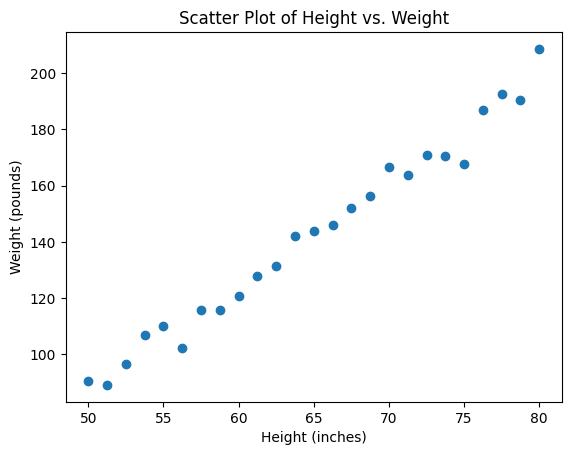

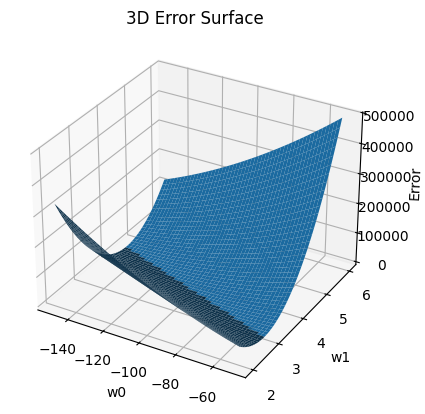

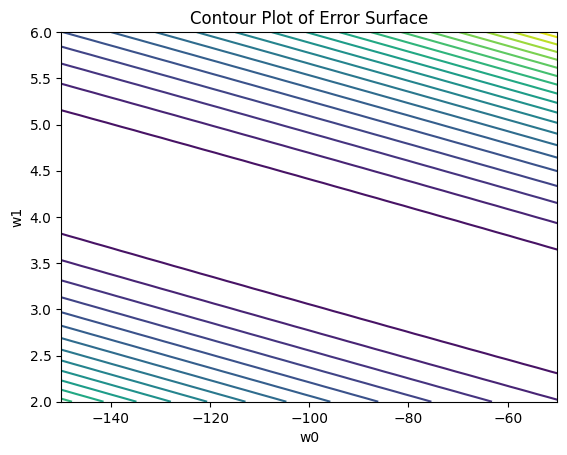

Empirically located minimum: w0 = -98.9795918367347 , w1 = 3.7142857142857144
Estimated weights using least squares: [-98.43955386   3.7083784 ]


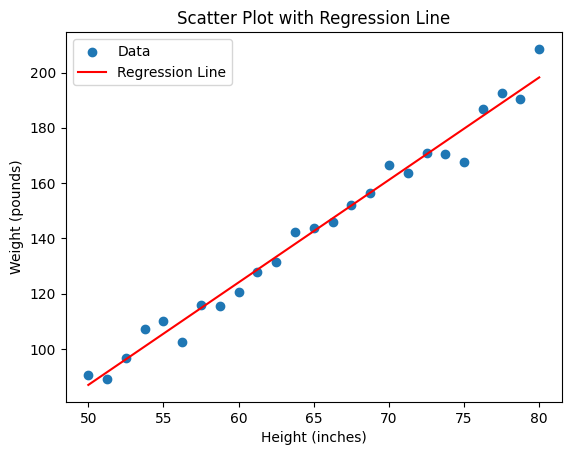

Comparison:
Empirically located minimum: w0 = -98.9795918367347 , w1 = 3.7142857142857144
Estimated weights using least squares: [-98.43955386   3.7083784 ]


In [ ]:
#Understanding Error Surface
#All imports
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import collections

########################################
#Generate meaningfull data
########################################
np.random.seed(0)  # For reproducibility
x = np.linspace(50, 80, 25)  # Human height (inches)
noise = np.random.normal(0, np.sqrt(20), 25)
t = 3.86 * x - 110.42 + noise # Human weight (pounds) with noise

########################################
#Plot scatter plot of data
########################################
plt.scatter(x, t)
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")
plt.title("Scatter Plot of Height vs. Weight")
plt.show()

########################################
#Weight estimation through error surface, i.e., empirically locate the minima of error surface
########################################
#Sample a bunch of w's around w_opt and compute the associated error
w0_range = np.linspace(-150, -50, 50)
w1_range = np.linspace(2, 6, 50)
W0, W1 = np.meshgrid(w0_range, w1_range)

#Compute the error
def Error(w,t,x): #inputs : 1)weight 2)data i.e (t,x)
    #Estimate the target
    t_pred = w[0] + w[1] * x  # Predicted target
    #Compute and return the error
    error = 0.5 * np.sum((t - t_pred)**2)  # Mean squared error
    return error

#Plot 3D error surface and the corresponding contour plots
#Error surface is a function of w0 and w1
Error_surface = np.zeros(W0.shape)
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        Error_surface[i, j] = Error([W0[i, j], W1[i, j]], t, x)

# 3D Error Surface Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0, W1, Error_surface)
ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.set_zlabel('Error')
plt.title('3D Error Surface')
plt.show()

# Contour Plot
plt.contour(W0, W1, Error_surface, levels=20)  # Adjust levels as needed
plt.xlabel('w0')
plt.ylabel('w1')
plt.title('Contour Plot of Error Surface')
plt.show()

#Locate the minima of the error surface
min_index = np.unravel_index(np.argmin(Error_surface), Error_surface.shape)
w0_min = W0[min_index]
w1_min = W1[min_index]
print("Empirically located minimum: w0 =", w0_min, ", w1 =", w1_min)

########################################
#Least squares approach to estimate the weights
########################################
#Complete the below linear regression function
def LinearRegression(x,t): #inputs : 1)input data i.e (x). 2)target i.e (t)
    X = np.vstack([np.ones(x.shape), x]).T
    w_opt = np.linalg.solve(X.T @ X, X.T @ t)
    return w_opt

#Estimate optimal weight's using "LinearRegression" function
w_opt = LinearRegression(x, t)
print("Estimated weights using least squares:", w_opt)

#Estimate the targets using the input x and the estimated weights
t_pred = w_opt[0] + w_opt[1] * x

#Plot the estimated line on top of the above scatter plot
plt.scatter(x, t, label='Data')
plt.plot(x, t_pred, color='red', label='Regression Line')
plt.xlabel("Height (inches)")
plt.ylabel("Weight (pounds)")
plt.title("Scatter Plot with Regression Line")
plt.legend()
plt.show()

########################################
#Compare the estimated weight's using least squares approach with the error surface approach
########################################
print("Comparison:")
print("Empirically located minimum: w0 =", w0_min, ", w1 =", w1_min)
print("Estimated weights using least squares:", w_opt)

<b> Report your observations </b>

1. The scatter plot shows the relationship between height vs weight.The data points exhibit a linear trend, indicating that weight generally increases with height.The noise added to the data creates some variability, making the relationship imperfect but still clearly linear(close to linear).

2.The 3D error surface plot visualizes the mean squared error as a function of the weights and the contour plot shows concentric ellipses, with the center representing the minimum error.The empirically located minimum of the error surface is close to the true optimal weights, demonstrating that the error surface approach can approximate the solution.

3.The empirically located minimum from the error surface approach and the weights estimated using the least squares method are very close.This confirms that the least squares method provides an exact solution, while the error surface approach approximates it through sampling.The regression line plotted using the least squares weights fits the data well, further validating the results



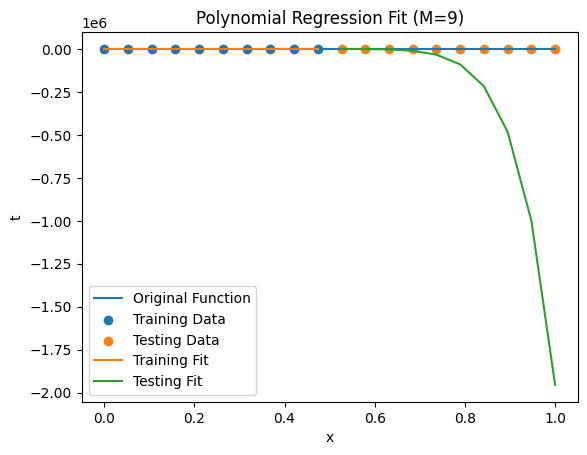

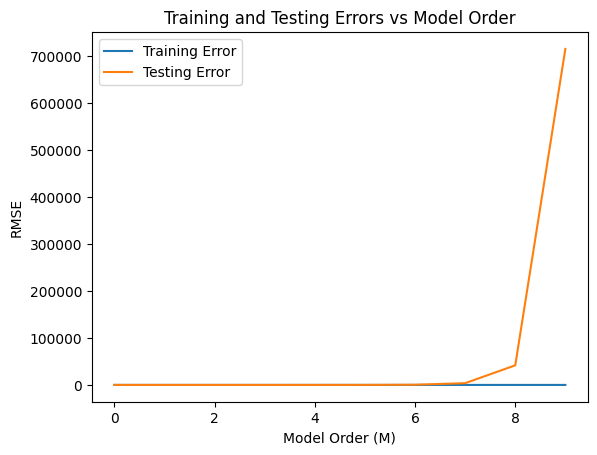

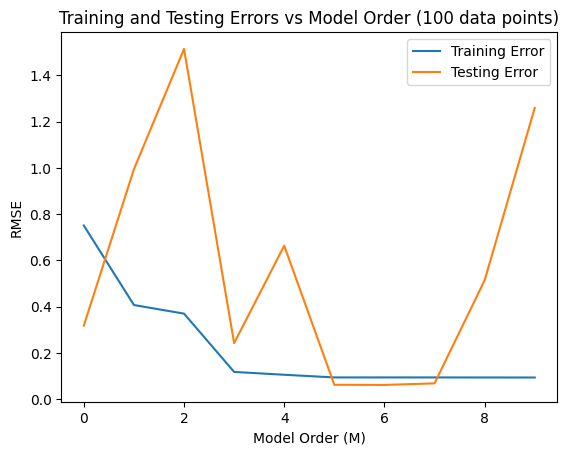

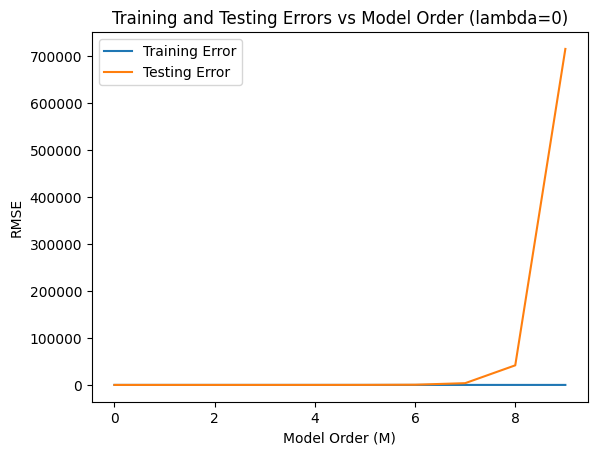

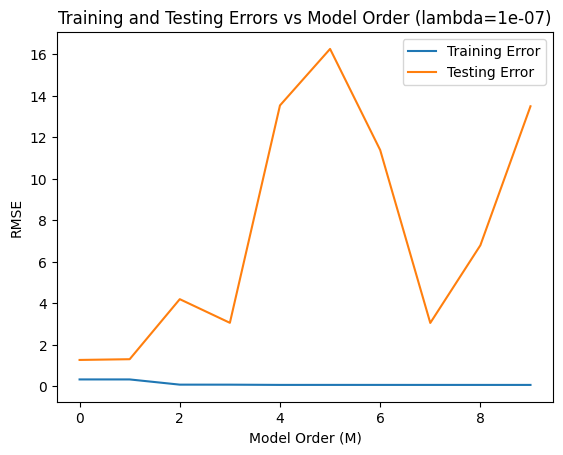

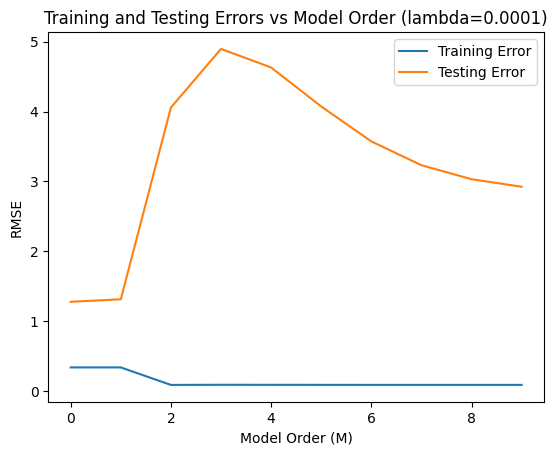

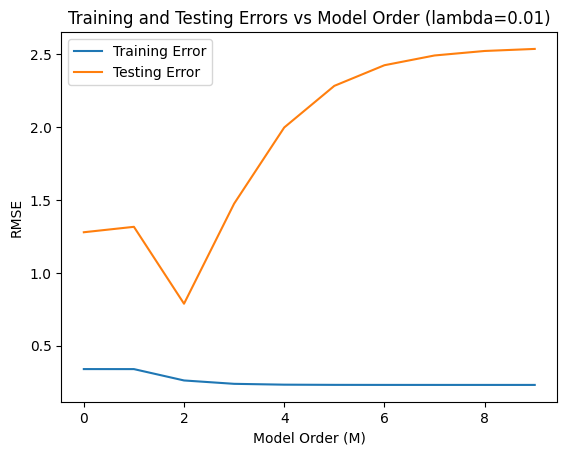

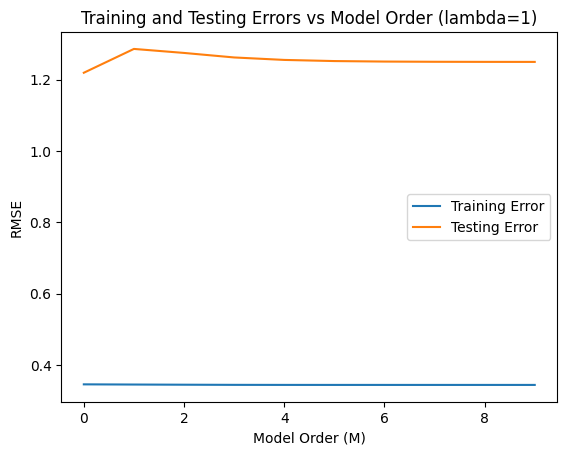

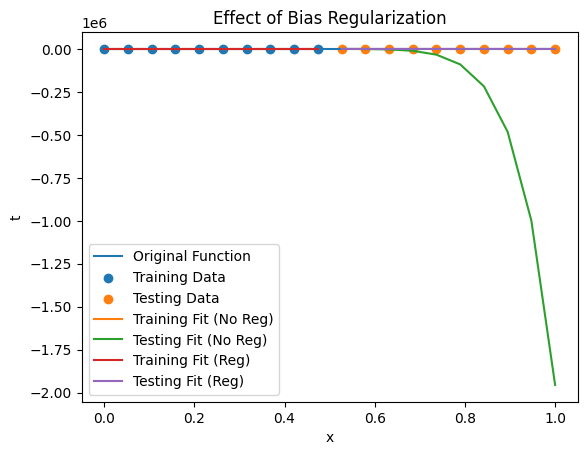

In [ ]:
#Understanding model order and overfitting
import numpy as np
import matplotlib.pyplot as plt

########################################
#Generate 20 data points
########################################
np.random.seed(0)  # For reproducibility
x = np.linspace(0, 1, 20)  # Input values
noise = np.random.normal(0, 0.1, 20)  # Gaussian noise
t = np.sin(2 * np.pi * x) + noise  # Target values

#Obtain train and test splits
X_train = x[:10]
Y_train = t[:10]
X_test = x[10:]
Y_test = t[10:]

########################################
#Fitting Mth degree polynomial using least squares approach
########################################
#Complete the function
def PolynomialFit(X_train,Y_train,M,lamda=0): #(training data, trining targets, Model order, Regularization coefficient)
    #Transform the data using polynomial kernel
    X = np.vander(X_train, M + 1, increasing=True) # Vandermonde matrix for polynomial features
    #Find Pseudo inverse solution
    if lamda == 0:
        w_opt = np.linalg.solve(X.T @ X, X.T @ Y_train)  # Without regularization
    else:
        w_opt = np.linalg.solve(X.T @ X + lamda * np.eye(M + 1), X.T @ Y_train)  # With regularization
    #return the weight vector
    return w_opt

#Complete the function
def PolynomialPred(w_est,X_train,X_test): #(weight,training data, testing data, training targets, testing targets)
    #Estimate the targets for both training and testing data
    Y_train_pred = np.vander(X_train, len(w_est), increasing=True) @ w_est
    Y_test_pred = np.vander(X_test, len(w_est), increasing=True) @ w_est
    #Return training and testing predictions
    return Y_train_pred,Y_test_pred

#Complete the function
def PolynomialPred_Error(w_est,X_train,X_test,Y_train,Y_test): #(weight,training data, testing data, training targets, testing targets)
    #Estimate the targets for both training and testing data
    Y_train_pred = np.vander(X_train, len(w_est), increasing=True) @ w_est
    Y_test_pred = np.vander(X_test, len(w_est), increasing=True) @ w_est
    #Return training and testing error
    TrainError = np.sqrt(np.mean((Y_train - Y_train_pred)**2))  # RMSE
    TestError = np.sqrt(np.mean((Y_test - Y_test_pred)**2))  # RMSE
    return TrainError,TestError

#Iterate through range of M values
M_range=list(range(10))
TrError = []
TeError = []
for M in M_range:
    #Fit Mth order polynomial i.e estimate optimal w. Use the function "PolynomialFit"
    w_opt = PolynomialFit(X_train, Y_train, M)
    #Predict training and testing targets
    Y_train_pred,Y_test_pred = PolynomialPred(w_opt,X_train,X_test)
    #Predict errors on both training and testing data using estimated w. Use the function "PolynomialPred_Error"
    TrainError, TestError = PolynomialPred_Error(w_opt, X_train, X_test, Y_train, Y_test)
    #Store them for plotting
    TrError.append(TrainError)
    TeError.append(TestError)

#Plot training and testing estimates alogwith the original targets
plt.plot(x, t, label='Original Function')
plt.scatter(X_train, Y_train, label='Training Data')
plt.scatter(X_test, Y_test, label='Testing Data')
plt.plot(X_train, Y_train_pred, label='Training Fit')
plt.plot(X_test, Y_test_pred, label='Testing Fit')
plt.xlabel("x")
plt.ylabel("t")
plt.title("Polynomial Regression Fit (M=9)")
plt.legend()
plt.show()

#Plot training error vs polynomial order, and testing error vs polynomial order
plt.plot(M_range, TrError, label='Training Error')
plt.plot(M_range, TeError, label='Testing Error')
plt.xlabel("Model Order (M)")
plt.ylabel("RMSE")
plt.title("Training and Testing Errors vs Model Order")
plt.legend()
plt.show()

########################################
#Increase the size of training data set to 100 points and repeat the experiments
########################################
np.random.seed(0)
x = np.linspace(0, 1, 100)
noise = np.random.normal(0, 0.1, 100)
t = np.sin(2 * np.pi * x) + noise

X_train = x[:90]
Y_train = t[:90]
X_test = x[90:]
Y_test = t[90:]

M_range = list(range(10))
TrError = []
TeError = []

for M in M_range:
    w_opt = PolynomialFit(X_train, Y_train, M)
    TrainError, TestError = PolynomialPred_Error(w_opt, X_train, X_test, Y_train, Y_test)
    TrError.append(TrainError)
    TeError.append(TestError)

plt.plot(M_range, TrError, label='Training Error')
plt.plot(M_range, TeError, label='Testing Error')
plt.xlabel("Model Order (M)")
plt.ylabel("RMSE")
plt.title("Training and Testing Errors vs Model Order (100 data points)")
plt.legend()
plt.show()

########################################
#Effect of regularization
########################################
#Consider a set of lambda's. For example: lamdas = [0, 1e-7 , 1e-4, 1e-2, 1]
#Repeat the experiments, i.e., plot the prediction and error in predictions with respect to model order. Contrast these results with those obtained without regularization.
np.random.seed(0)
x = np.linspace(0, 1, 20)
noise = np.random.normal(0, 0.1, 20)
t = np.sin(2 * np.pi * x) + noise

X_train = x[:10]
Y_train = t[:10]
X_test = x[10:]
Y_test = t[10:]

lamdas = [0, 1e-7, 1e-4, 1e-2, 1]

for lamda in lamdas:
    M_range = list(range(10))
    TrError = []
    TeError = []

    for M in M_range:
        w_opt = PolynomialFit(X_train, Y_train, M, lamda)
        TrainError, TestError = PolynomialPred_Error(w_opt, X_train, X_test, Y_train, Y_test)
        TrError.append(TrainError)
        TeError.append(TestError)

    plt.plot(M_range, TrError, label='Training Error')
    plt.plot(M_range, TeError, label='Testing Error')
    plt.xlabel("Model Order (M)")
    plt.ylabel("RMSE")
    plt.title(f"Training and Testing Errors vs Model Order (lambda={lamda})")
    plt.legend()
    plt.show()

########################################
#Effect of bias regularization
########################################
#Modify the function i.e include bias
#Generate data
np.random.seed(0)
x = np.linspace(0, 1, 20)
noise = np.random.normal(0, 0.1, 20)
t = 5 + np.sin(2 * np.pi * x) + noise  # Added bias term

X_train = x[:10]
Y_train = t[:10]
X_test = x[10:]
Y_test = t[10:]

#Estimate the polynomial with and without regularization constraint
M = 9  # Example model order
lamda = 1e-2  # Example regularization parameter

w_opt_no_reg = PolynomialFit(X_train, Y_train, M)
w_opt_reg = PolynomialFit(X_train, Y_train, M, lamda)

#Compare the two estimated polynomials and report the observations
Y_train_pred_no_reg, Y_test_pred_no_reg = PolynomialPred(w_opt_no_reg, X_train, X_test)
Y_train_pred_reg, Y_test_pred_reg = PolynomialPred(w_opt_reg, X_train, X_test)

plt.plot(x, t, label='Original Function')
plt.scatter(X_train, Y_train, label='Training Data')
plt.scatter(X_test, Y_test, label='Testing Data')
plt.plot(X_train, Y_train_pred_no_reg, label='Training Fit (No Reg)')
plt.plot(X_test, Y_test_pred_no_reg, label='Testing Fit (No Reg)')
plt.plot(X_train, Y_train_pred_reg, label='Training Fit (Reg)')
plt.plot(X_test, Y_test_pred_reg, label='Testing Fit (Reg)')
plt.xlabel("x")
plt.ylabel("t")
plt.title("Effect of Bias Regularization")
plt.legend()
plt.show()

<b> Report your observations </b>

1.When the model order M is high the polynomial fits the training data perfectly but performs poorly on the test data.This is evident from the training error being very low (close to 0) while the testing error is significantly higher, indicating overfitting.The plot of the polynomial fit shows a highly complex curve that passes through all training points but deviates from the true underlying function.

2. Increasing training data size reduces overfitting and improves generalizationThe testing error decreases significantly, and the gap between training and testing errors narrows, especially for higher model orders.This shows that more data helps reduce overfitting and improves the model's ability to generalize.

3.Regularization reduces overfitting by penalizing large weights.With regularization, the testing error is lower compared to the unregularized model, especially for high model orders.The polynomial fit with regularization is smoother and closer to the true underlying function, avoiding extreme oscillations seen in the unregularized model.



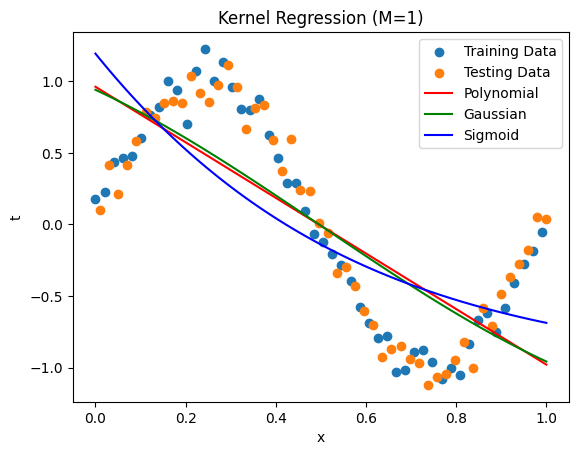

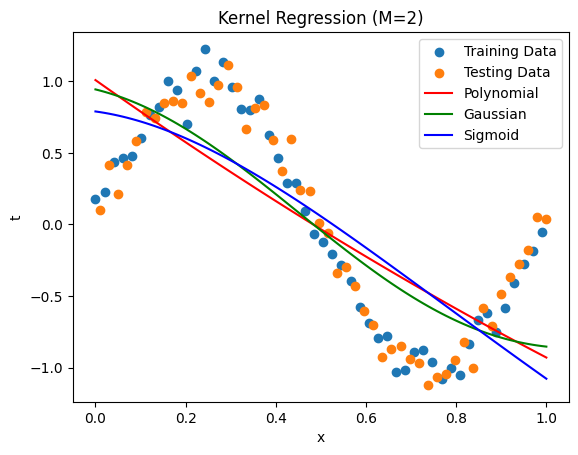

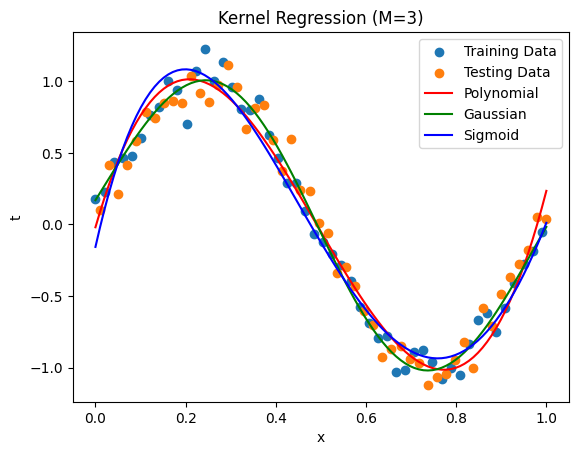

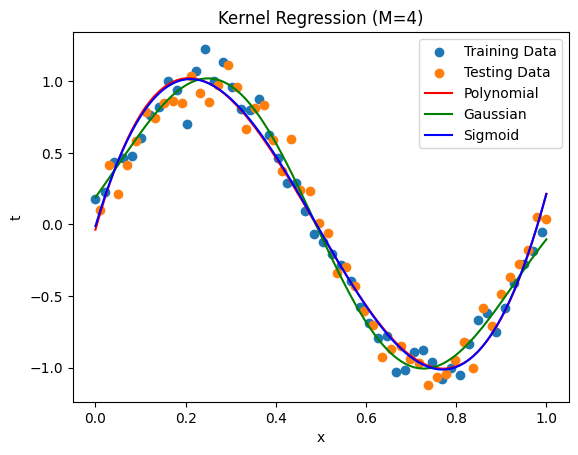

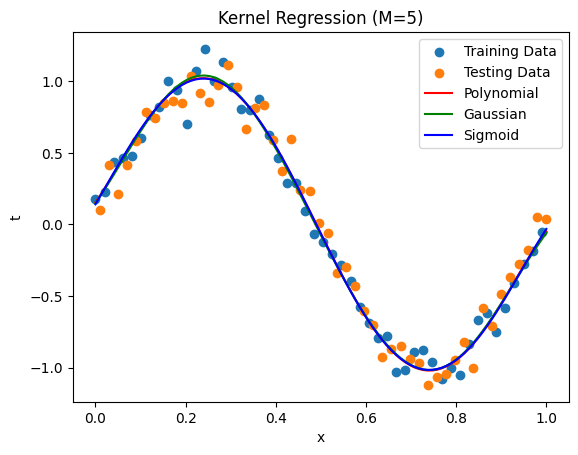

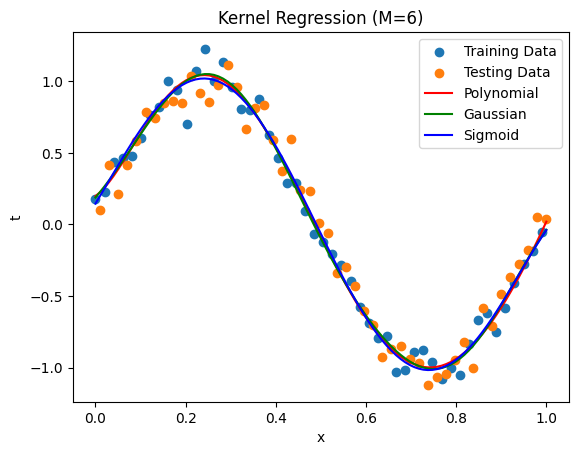

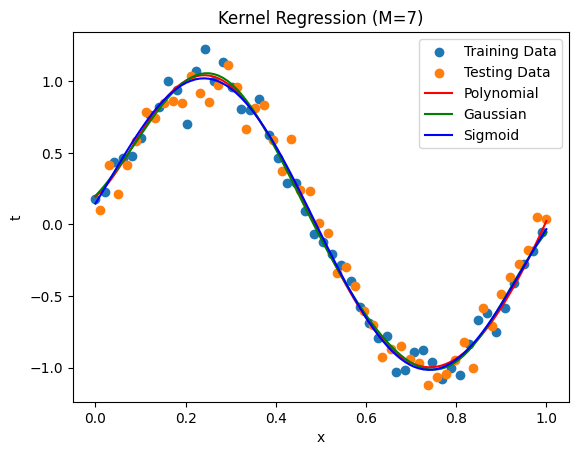

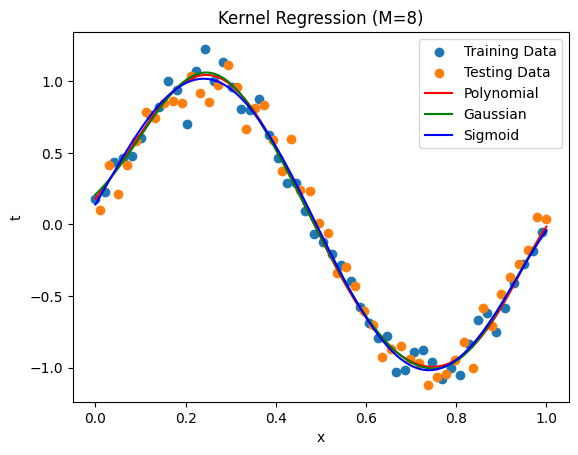

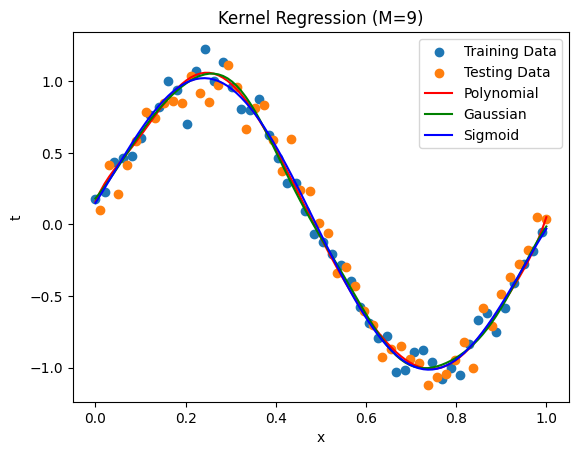

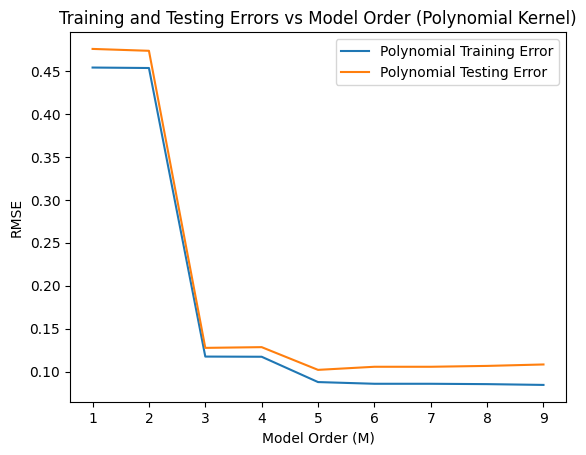

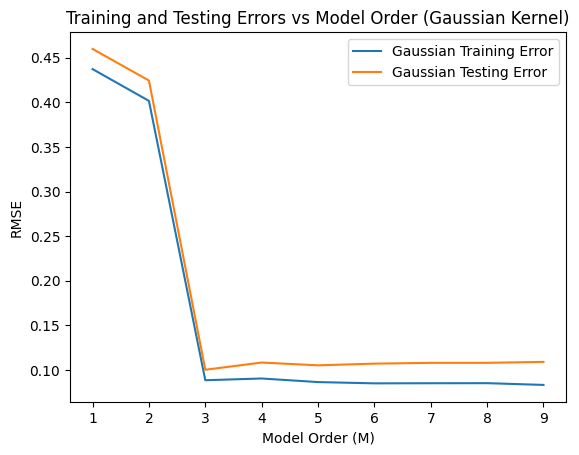

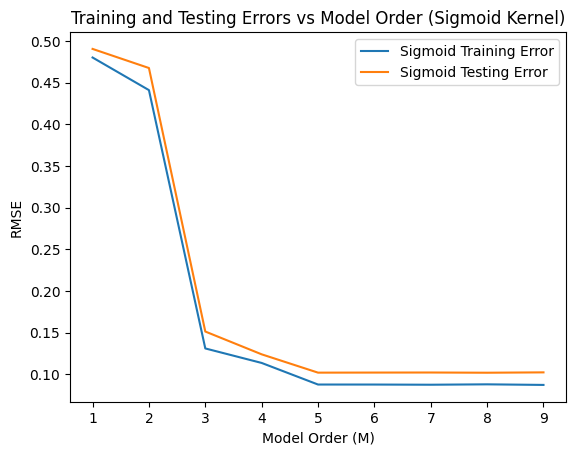

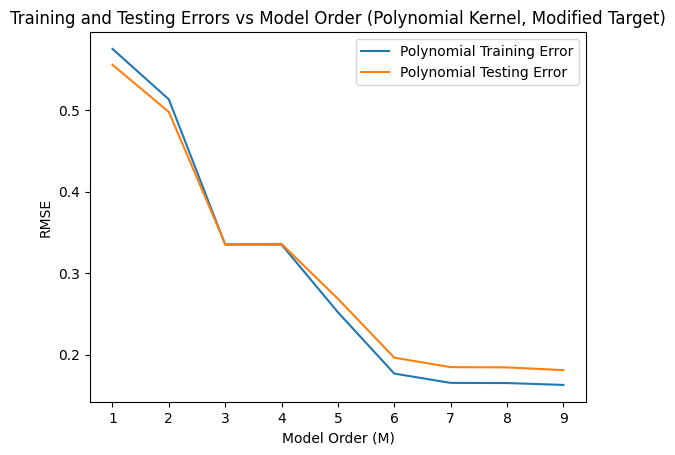

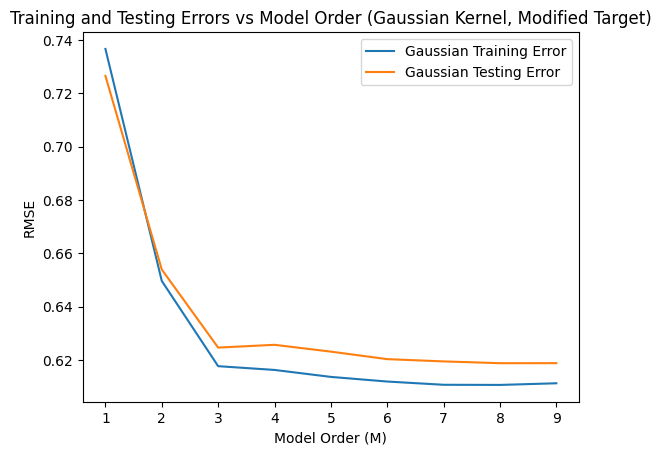

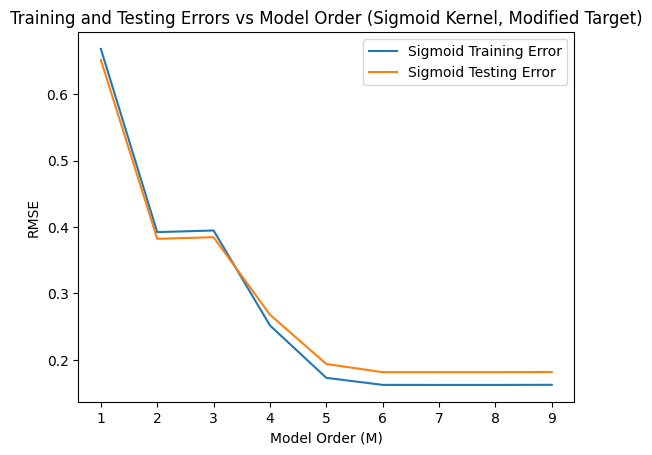

In [ ]:

# Understanding the choice of kernel
########################################
# Generate 100 data points
########################################
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
x = np.linspace(0, 1, 100)
noise = np.random.normal(0, 0.1, 100)
t = np.sin(2 * np.pi * x) + noise

# Obtain train and test splits
# Take even samples for training and odd samples for testing
X_train = x[::2]
Y_train = t[::2]
X_test = x[1::2]
Y_test = t[1::2]

# Function to estimate the parameters
def KernelRegressionFit(X_train, Y_train, kernelType, M, lamda):  # (training data, training targets, type of kernel, regularization coefficient)
    # kernelType : {Polynomial,Gaussian,Sigmoid}
    X = []
    if kernelType == 'polynomial':
        # Use polynomial kernel to transform the data
        X = np.vander(X_train, M + 1, increasing=True)
    if kernelType == 'gaussian':
        # Use Gaussian kernel to transform the data
        X = np.zeros((len(X_train), M + 1))
        for i in range(len(X_train)):
            for j in range(M + 1):
                X[i, j] = np.exp(-(X_train[i] - j / M)**2 / (2 * (1 / M)**2))
    if kernelType == 'sigmoidal':
        # Use Sigmoid kernel to transform the data
        X = np.zeros((len(X_train), M + 1))
        for i in range(len(X_train)):
            for j in range(M + 1):
                X[i, j] = np.tanh(X_train[i] * j / M + 1)

    # Estimate weights using Pseudo inverse solution
    w_opt = np.linalg.solve(X.T @ X + lamda * np.eye(X.shape[1]), X.T @ Y_train)

    # Return the estimated weights
    return w_opt

# Function to compute the training and testing errors
def KernelRegressionPred_Error(w_est, X_train, Y_train, X_test, Y_test, kernelType):
    # kernelType : {Polynomial,Gaussian,Sigmoid}
    X_tr = []
    X_te = []
    M = len(w_est) - 1

    if kernelType == 'polynomial':
        # Use polynomial kernel to transform the data
        X_tr = np.vander(X_train, len(w_est), increasing=True)
        X_te = np.vander(X_test, len(w_est), increasing=True)
    elif kernelType == 'gaussian':
        # Use Gaussian kernel to transform the data
        X_tr = np.zeros((len(X_train), M + 1))
        for i in range(len(X_train)):
            for j in range(M + 1):
                X_tr[i, j] = np.exp(-(X_train[i] - j / M)**2 / (2 * (1 / M)**2))
        X_te = np.zeros((len(X_test), M + 1))
        for i in range(len(X_test)):
            for j in range(M + 1):
                X_te[i, j] = np.exp(-(X_test[i] - j / M)**2 / (2 * (1 / M)**2))
    elif kernelType == 'sigmoidal':
        # Use Sigmoid kernel to transform the data
        X_tr = np.zeros((len(X_train), M + 1))
        for i in range(len(X_train)):
            for j in range(M + 1):
                X_tr[i, j] = np.tanh(X_train[i] * j / M + 1)
        X_te = np.zeros((len(X_test), M + 1))
        for i in range(len(X_test)):
            for j in range(M + 1):
                X_te[i, j] = np.tanh(X_test[i] * j / M + 1)

    # Estimate training and testing targets
    Y_train_pred = X_tr @ w_est
    Y_test_pred = X_te @ w_est

    # Compute and return the training and testing errors
    TrainError = np.sqrt(np.mean((Y_train - Y_train_pred)**2))  # RMSE
    TestError = np.sqrt(np.mean((Y_test - Y_test_pred)**2))  # RMSE
    return TrainError, TestError


# Iterate through range of M values
M_range = list(range(1, 10))  # M values from 1 to 9

for M in M_range:
    # Fit Mth order polynomial using three kernels
    w_opt_polynomial = KernelRegressionFit(X_train, Y_train, 'polynomial', M, lamda=0)
    w_opt_gaussian = KernelRegressionFit(X_train, Y_train, 'gaussian', M, lamda=0)
    w_opt_sigmoid = KernelRegressionFit(X_train, Y_train, 'sigmoidal', M, lamda=0)

    # Generate x values for plotting the curves
    x_plot = np.linspace(0, 1, 100)

    # Predict targets for plotting using estimated weights
    Y_plot_polynomial = np.vander(x_plot, len(w_opt_polynomial), increasing=True) @ w_opt_polynomial

    # Modified Gaussian prediction for plotting
    X_plot_gaussian = np.zeros((len(x_plot), M + 1))
    for i in range(len(x_plot)):
        for j in range(M + 1):
            X_plot_gaussian[i, j] = np.exp(-(x_plot[i] - j / M)**2 / (2 * (1 / M)**2))
    Y_plot_gaussian = X_plot_gaussian @ w_opt_gaussian

    # Modified Sigmoid prediction for plotting
    X_plot_sigmoid = np.zeros((len(x_plot), M + 1))
    for i in range(len(x_plot)):
        for j in range(M + 1):
            X_plot_sigmoid[i, j] = np.tanh(x_plot[i] * j / M + 1)
    Y_plot_sigmoid = X_plot_sigmoid @ w_opt_sigmoid

    # Create individual plots for each M value
    plt.figure()
    plt.scatter(X_train, Y_train, label='Training Data')
    plt.scatter(X_test, Y_test, label='Testing Data')
    plt.plot(x_plot, Y_plot_polynomial, label='Polynomial', color='red')
    plt.plot(x_plot, Y_plot_gaussian, label='Gaussian', color='green')
    plt.plot(x_plot, Y_plot_sigmoid, label='Sigmoid', color='blue')
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title(f"Kernel Regression (M={M})")
    plt.legend()
    plt.show()

# Iterate through range of M values for error plotting
M_range = list(range(1, 10))  # M values from 1 to 9

polynomial_tr_error = []
polynomial_te_error = []
gaussian_tr_error = []
gaussian_te_error = []
sigmoid_tr_error = []
sigmoid_te_error = []

for M in M_range:
    # Fit Mth order polynomial using three kernels
    w_opt_polynomial = KernelRegressionFit(X_train, Y_train, 'polynomial', M, lamda=0)
    w_opt_gaussian = KernelRegressionFit(X_train, Y_train, 'gaussian', M, lamda=0)
    w_opt_sigmoid = KernelRegressionFit(X_train, Y_train, 'sigmoidal', M, lamda=0)

    # Predict errors on both training and testing data using estimated w
    TrainError_polynomial, TestError_polynomial = KernelRegressionPred_Error(
        w_opt_polynomial, X_train, Y_train, X_test, Y_test, 'polynomial'
    )
    TrainError_gaussian, TestError_gaussian = KernelRegressionPred_Error(
        w_opt_gaussian, X_train, Y_train, X_test, Y_test, 'gaussian'
    )
    TrainError_sigmoid, TestError_sigmoid = KernelRegressionPred_Error(
        w_opt_sigmoid, X_train, Y_train, X_test, Y_test, 'sigmoidal'
    )

    # Store errors for plotting
    polynomial_tr_error.append(TrainError_polynomial)
    polynomial_te_error.append(TestError_polynomial)
    gaussian_tr_error.append(TrainError_gaussian)
    gaussian_te_error.append(TestError_gaussian)
    sigmoid_tr_error.append(TrainError_sigmoid)
    sigmoid_te_error.append(TestError_sigmoid)

# Polynomial Kernel
plt.plot(M_range, polynomial_tr_error, label='Polynomial Training Error')
plt.plot(M_range, polynomial_te_error, label='Polynomial Testing Error')
plt.xlabel("Model Order (M)")
plt.ylabel("RMSE")
plt.title("Training and Testing Errors vs Model Order (Polynomial Kernel)")
plt.legend()
plt.show()
# Gaussian Kernel
plt.plot(M_range, gaussian_tr_error, label='Gaussian Training Error')
plt.plot(M_range, gaussian_te_error, label='Gaussian Testing Error')
plt.xlabel("Model Order (M)")
plt.ylabel("RMSE")
plt.title("Training and Testing Errors vs Model Order (Gaussian Kernel)")
plt.legend()
plt.show()
# Sigmoid Kernel
plt.plot(M_range, sigmoid_tr_error, label='Sigmoid Training Error')
plt.plot(M_range, sigmoid_te_error, label='Sigmoid Testing Error')
plt.xlabel("Model Order (M)")
plt.ylabel("RMSE")
plt.title("Training and Testing Errors vs Model Order (Sigmoid Kernel)")
plt.legend()
plt.show()
########################################
# Repeat the experiments by changing target function
########################################
# Generate 100 data points with a modified target function
np.random.seed(0)
x = np.linspace(0, 3, 300)
noise = np.random.normal(0, 0.1, 300)
t = np.zeros(300)
t[:100] = np.sin(2 * np.pi * x[:100]) + noise[:100]  # Sinusoid for x in [0, 1)
t[100:200] = (x[100:200] - 1) - (x[100:200] - 2)**2 + noise[100:200]  # Triangle for x in [1, 2)
t[200:] = np.exp(-(x[200:] - 2.5)**2) + noise[200:]  # Gaussian for x in [2, 3)

# Obtain train and test splits (same as before)
X_train = x[::2]
Y_train = t[::2]
X_test = x[1::2]
Y_test = t[1::2]

# Repeat the same process as above, using the modified target function
polynomial_tr_error = []
polynomial_te_error = []
gaussian_tr_error = []
gaussian_te_error = []
sigmoid_tr_error = []
sigmoid_te_error = []

for M in M_range:
    # Fit Mth order polynomial using three kernels
    w_opt_polynomial = KernelRegressionFit(X_train, Y_train, 'polynomial', M, lamda=0)
    w_opt_gaussian = KernelRegressionFit(X_train, Y_train, 'gaussian', M, lamda=0)
    w_opt_sigmoid = KernelRegressionFit(X_train, Y_train, 'sigmoidal', M, lamda=0)

    # Predict errors on both training and testing data using estimated w
    TrainError_polynomial, TestError_polynomial = KernelRegressionPred_Error(
        w_opt_polynomial, X_train, Y_train, X_test, Y_test, 'polynomial'
    )
    TrainError_gaussian, TestError_gaussian = KernelRegressionPred_Error(
        w_opt_gaussian, X_train, Y_train, X_test, Y_test, 'gaussian'
    )
    TrainError_sigmoid, TestError_sigmoid = KernelRegressionPred_Error(
        w_opt_sigmoid, X_train, Y_train, X_test, Y_test, 'sigmoidal'
    )

    # Store errors for plotting
    polynomial_tr_error.append(TrainError_polynomial)
    polynomial_te_error.append(TestError_polynomial)
    gaussian_tr_error.append(TrainError_gaussian)
    gaussian_te_error.append(TestError_gaussian)
    sigmoid_tr_error.append(TrainError_sigmoid)
    sigmoid_te_error.append(TestError_sigmoid)

# Polynomial Kernel
plt.plot(M_range, polynomial_tr_error, label='Polynomial Training Error')
plt.plot(M_range, polynomial_te_error, label='Polynomial Testing Error')
plt.xlabel("Model Order (M)")
plt.ylabel("RMSE")
plt.title("Training and Testing Errors vs Model Order (Polynomial Kernel, Modified Target)")
plt.legend()
plt.show()
# Gaussian Kernel
plt.plot(M_range, gaussian_tr_error, label='Gaussian Training Error')
plt.plot(M_range, gaussian_te_error, label='Gaussian Testing Error')
plt.xlabel("Model Order (M)")
plt.ylabel("RMSE")
plt.title("Training and Testing Errors vs Model Order (Gaussian Kernel, Modified Target)")
plt.legend()
plt.show()
# Sigmoid Kernel
plt.plot(M_range, sigmoid_tr_error, label='Sigmoid Training Error')
plt.plot(M_range, sigmoid_te_error, label='Sigmoid Testing Error')
plt.xlabel("Model Order (M)")
plt.ylabel("RMSE")
plt.title("Training and Testing Errors vs Model Order (Sigmoid Kernel, Modified Target)")
plt.legend()
plt.show()

<b> Report your observations </b>

1.Polynomial Kernel: Performs well for simple, smooth functions but struggles with complex, non-linear patterns, leading to overfitting at higher model orders.
2.Gaussian Kernel: Adapts better to complex, non-linear data due to its localized nature, providing smoother fits and lower testing errors compared to polynomial kernels.

3.Sigmoid Kernel: Less effective for regression tasks, often producing poor fits and higher errors, as it is more suited for classification problems



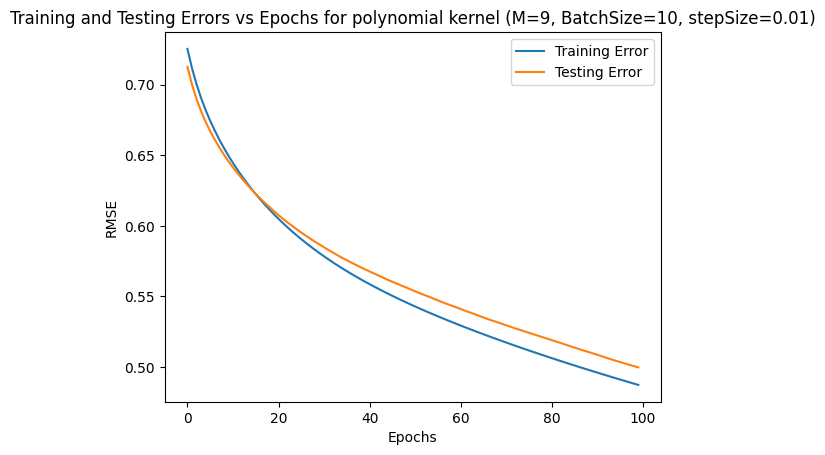

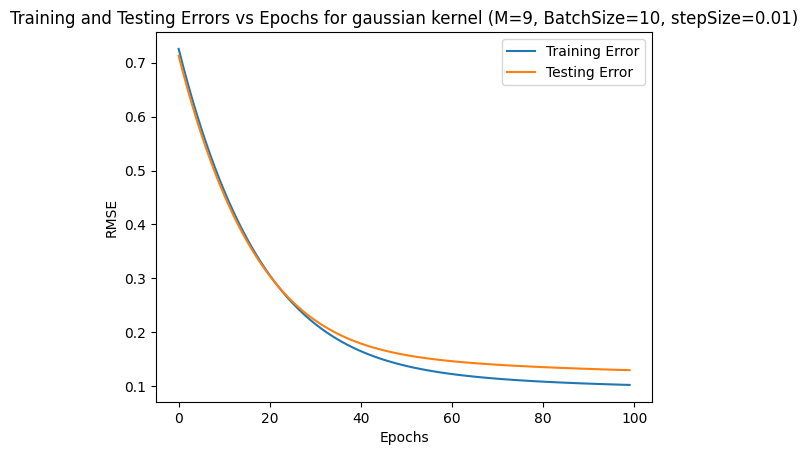

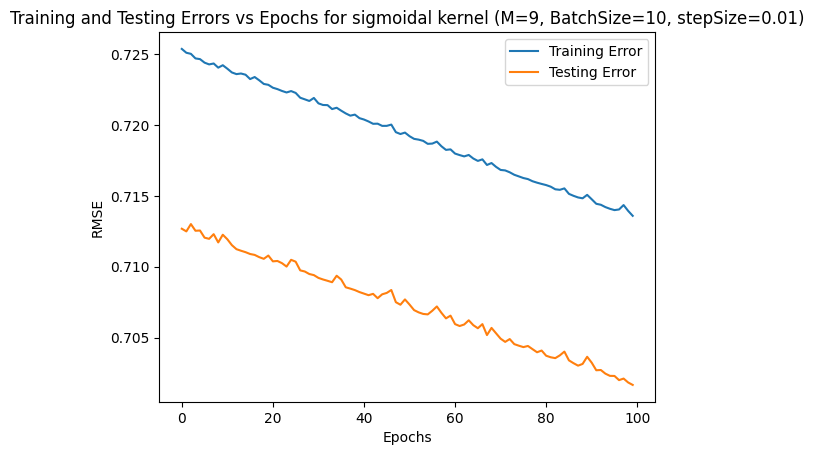

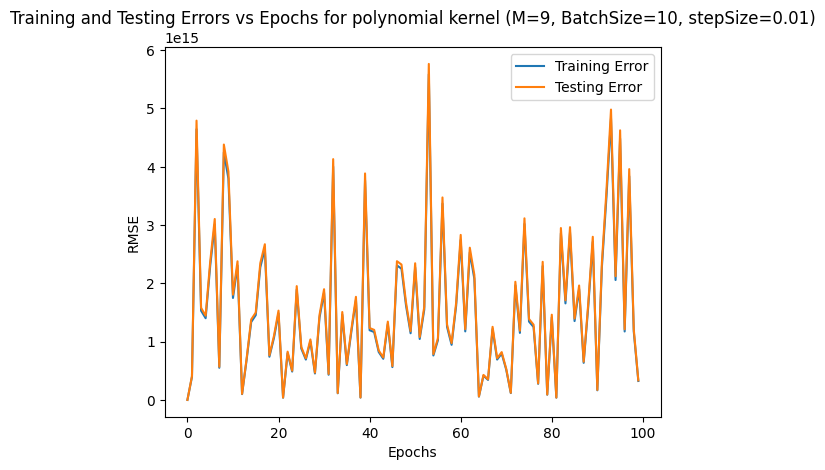

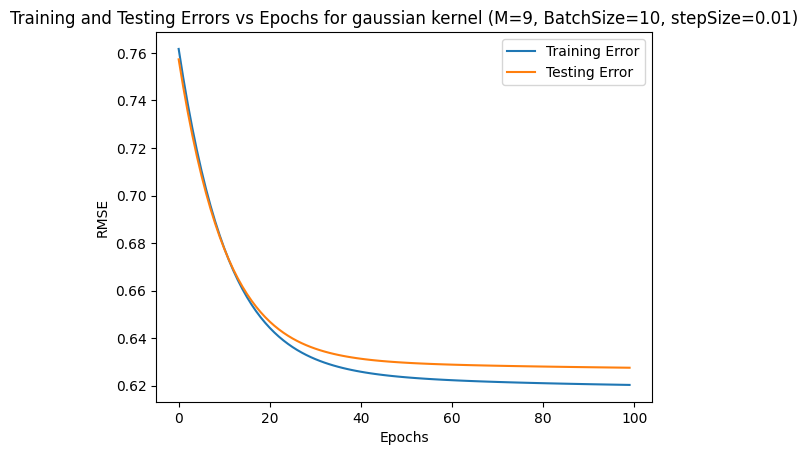

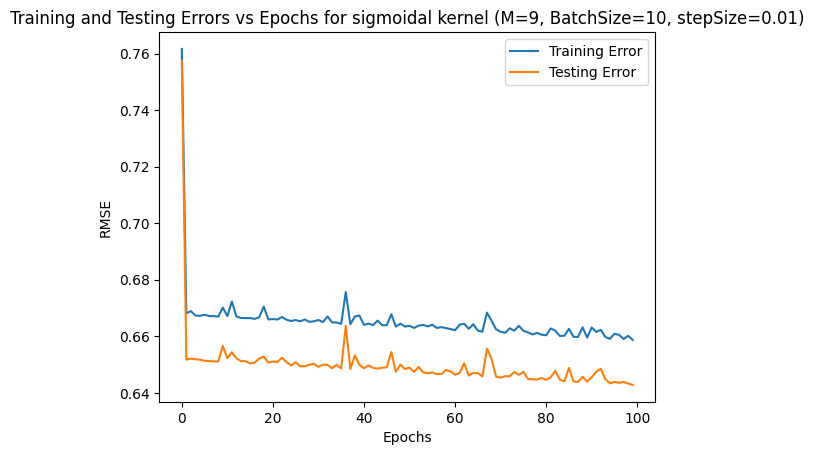

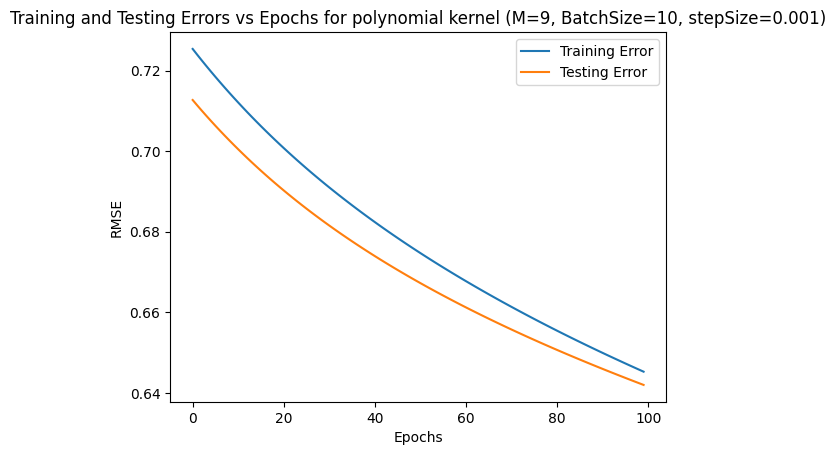

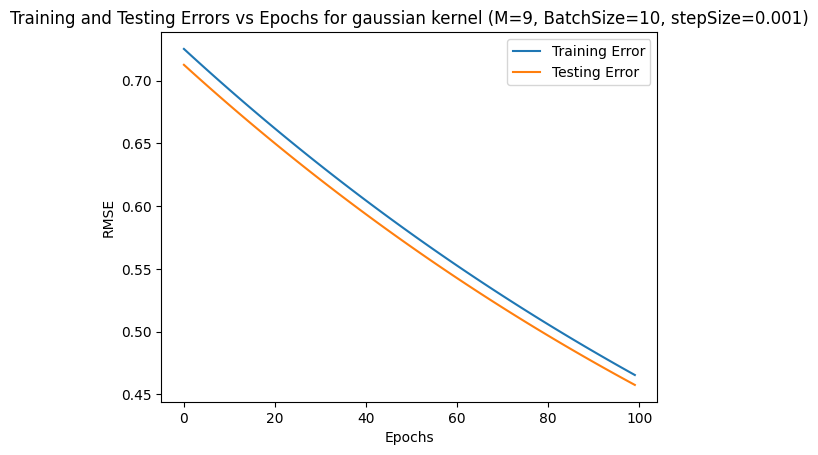

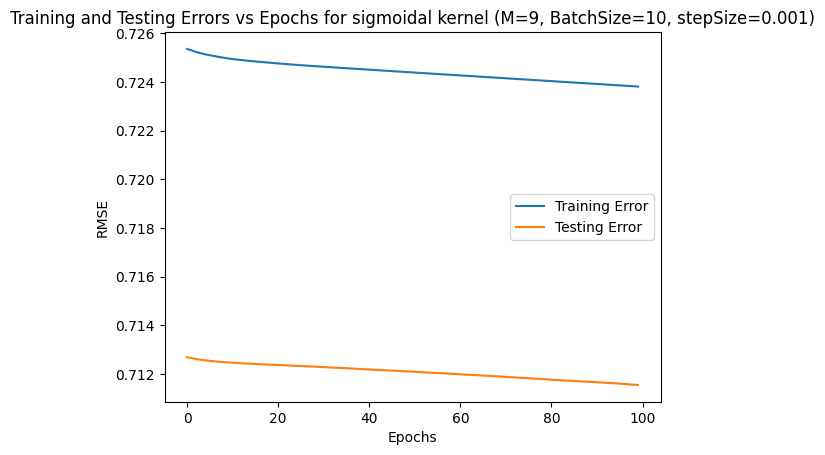

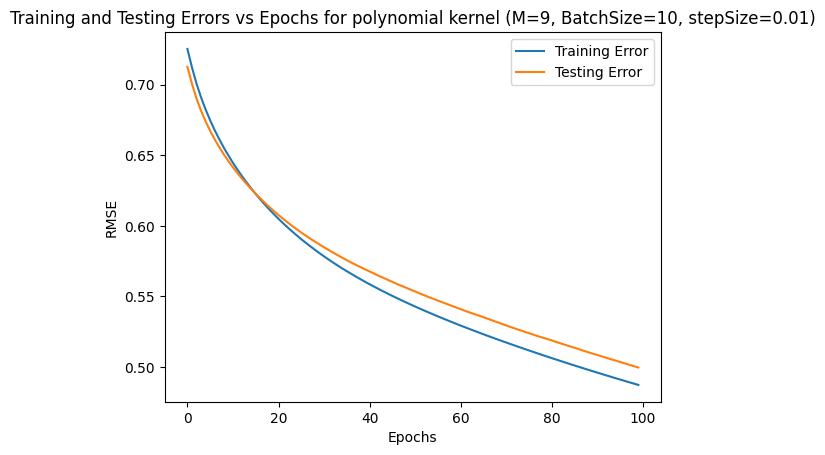

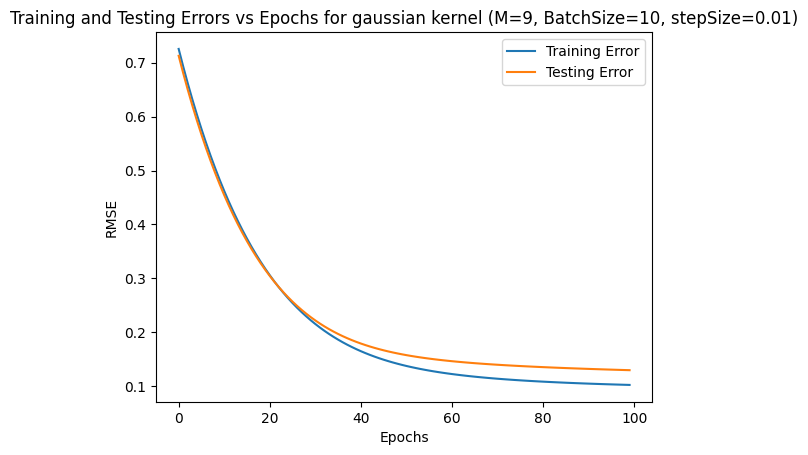

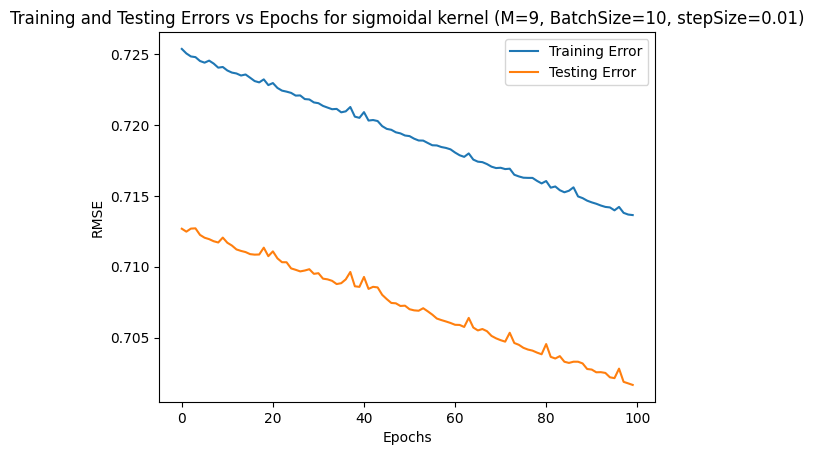

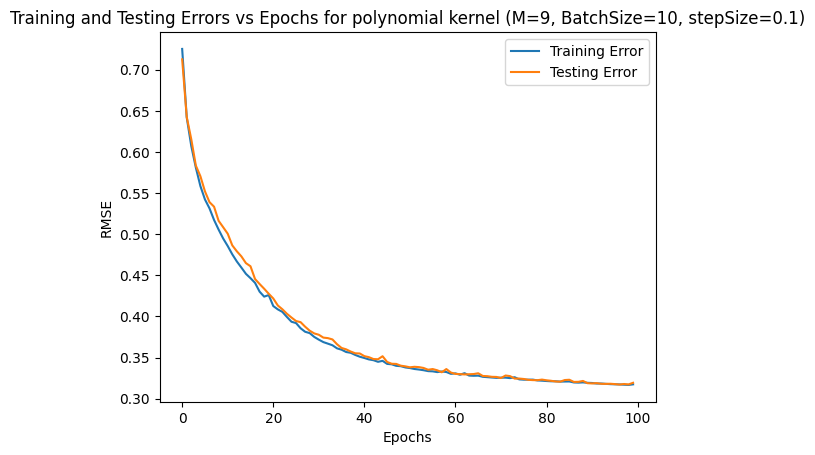

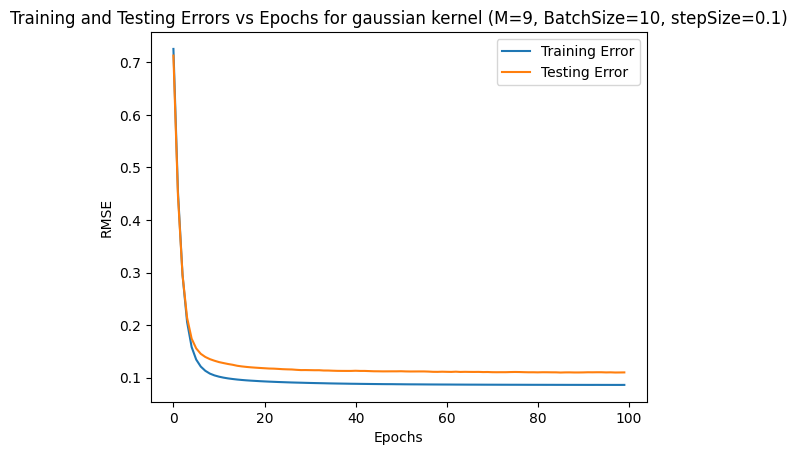

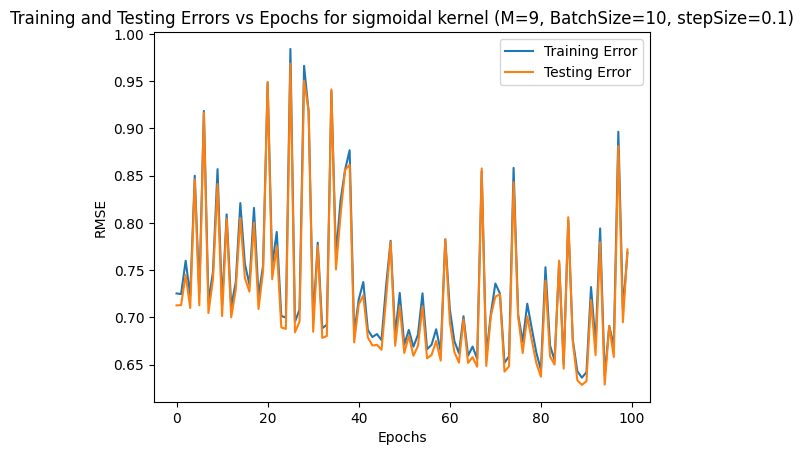

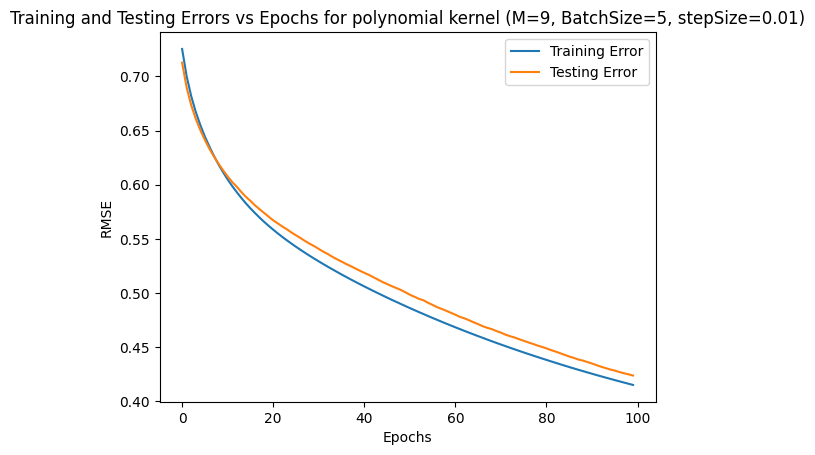

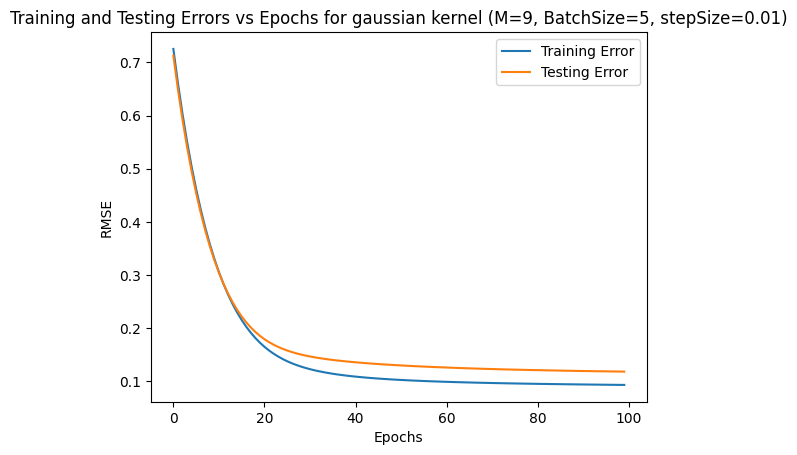

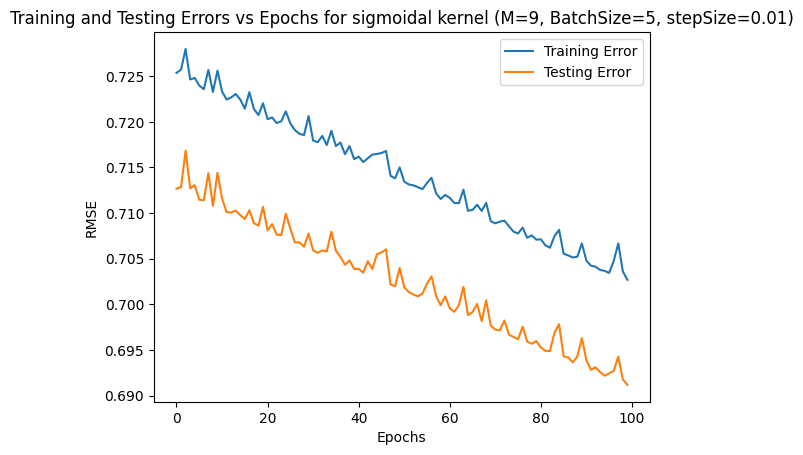

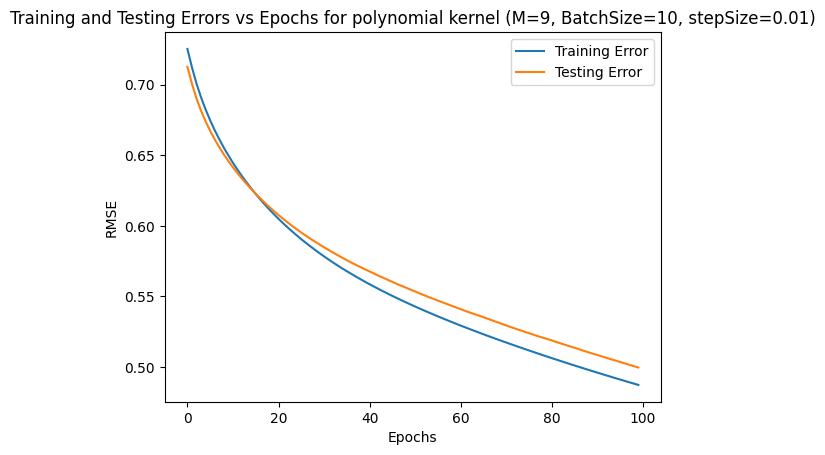

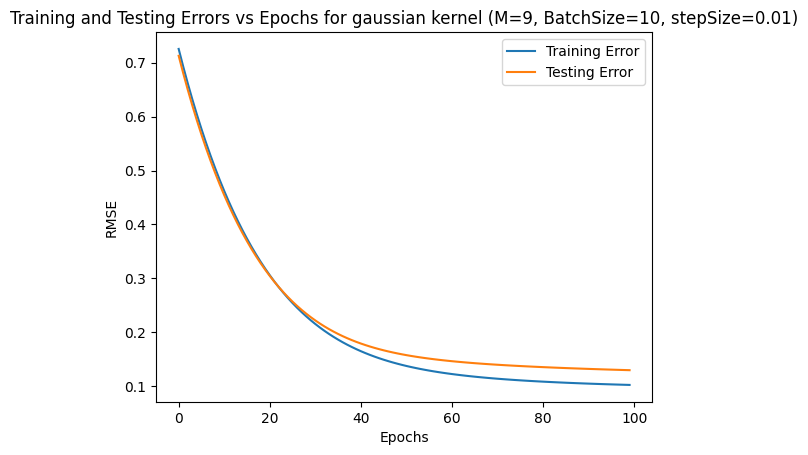

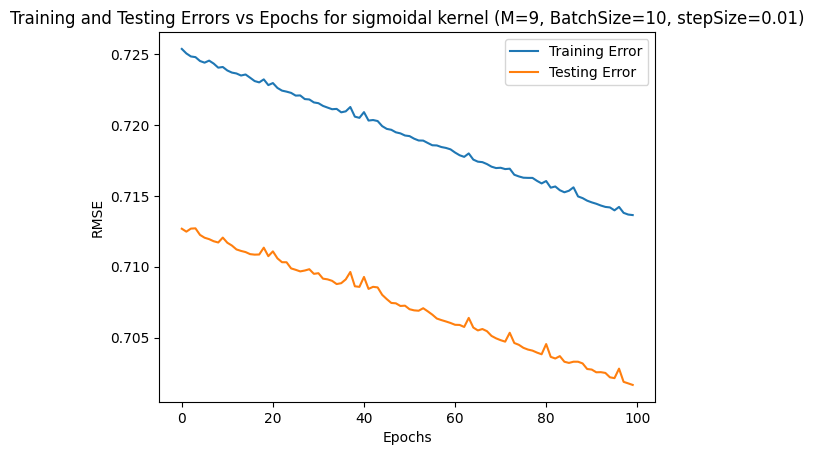

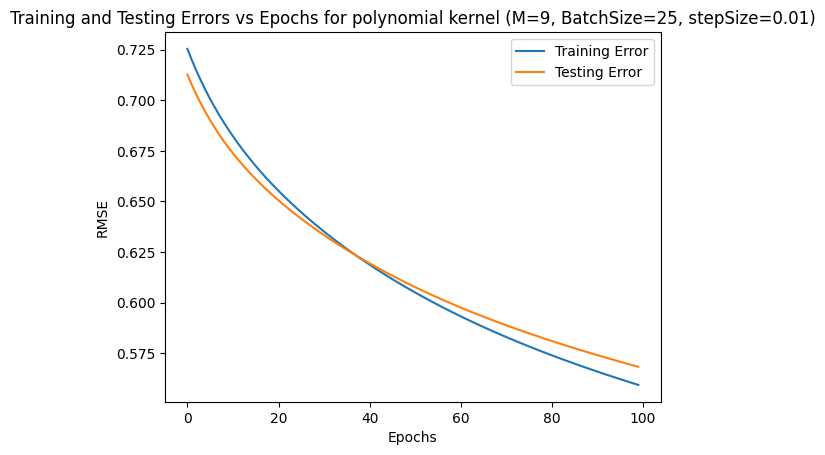

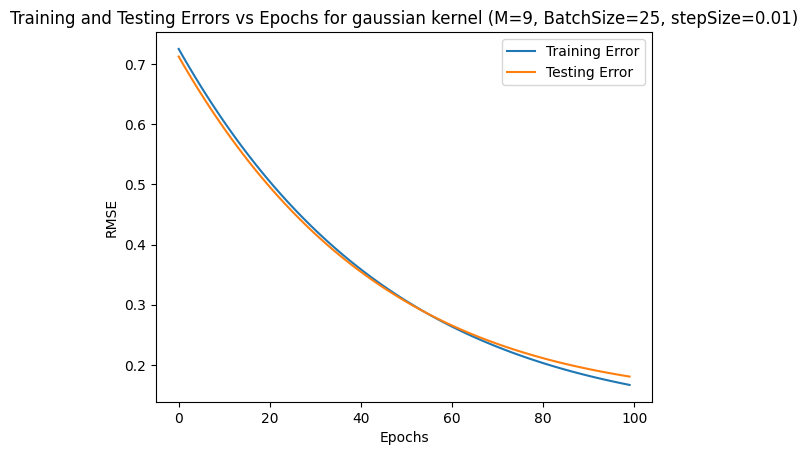

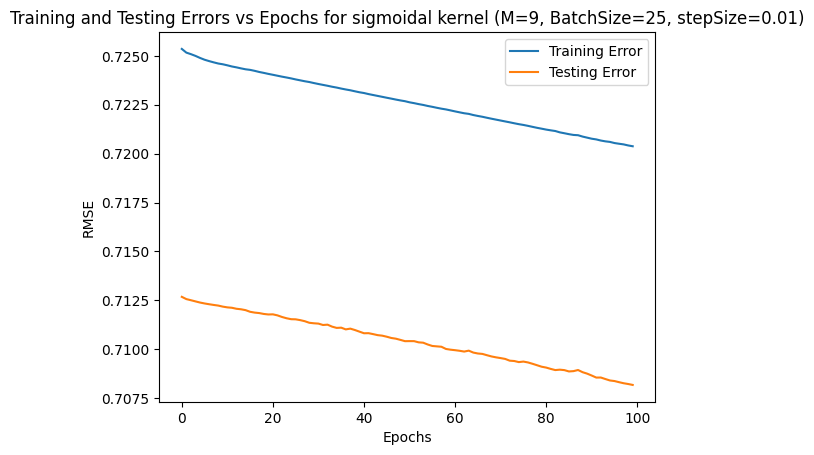

In [ ]:
#Understanding online training
########################################
#Repeat 3(a) and 3(b) using stochastic gradient descent for weight update ( plot required results )
########################################
import numpy as np
import matplotlib.pyplot as plt

def ErrorPred(w_est,X_train,Y_train,X_test,Y_test,kernelType): #(estimated weight, training data, training targets, testing data, testing targets, type of the kernel )
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    X_tr = []
    X_te = []
    M = len(w_est)-1
    if kernelType=='polynomial':
      #Use polynomial kernel to transform the data
      X_tr = np.vander(X_train, M + 1, increasing=True)
      X_te = np.vander(X_test, M + 1, increasing=True)
    if kernelType=='gaussian':
      #Use Gaussian kernel to transofrm the data
      X_tr = np.zeros((len(X_train), M + 1))
      for i in range(len(X_train)):
        for j in range(M + 1):
          X_tr[i, j] = np.exp(-(X_train[i] - j / M)**2 / (2 * (1 / M)**2))  #Gaussian Kernel
      X_te = np.zeros((len(X_test), M + 1))
      for i in range(len(X_test)):
        for j in range(M + 1):
          X_te[i, j] = np.exp(-(X_test[i] - j / M)**2 / (2 * (1 / M)**2))  #Gaussian Kernel
    if kernelType=='sigmoidal':
      #Use sigmoidal kernel to transform the data
      X_tr = np.zeros((len(X_train), M + 1))
      for i in range(len(X_train)):
        for j in range(M + 1):
          X_tr[i, j] = np.tanh(X_train[i] * j / M + 1)  #Sigmoidal Kernel
      X_te = np.zeros((len(X_test), M + 1))
      for i in range(len(X_test)):
        for j in range(M + 1):
          X_te[i, j] = np.tanh(X_test[i] * j / M + 1)  #Sigmoidal Kernel

    #Compute and return the train and test errors
    Y_train_pred = X_tr @ w_est
    Y_test_pred = X_te @ w_est
    TrainError = np.sqrt(np.mean((Y_train - Y_train_pred)**2))  # RMSE
    TestError = np.sqrt(np.mean((Y_test - Y_test_pred)**2))  # RMSE
    return TrainError, TestError


def OnlineTraining(X_train,Y_train,X_test, Y_test, kernelType,M,Epochs,BatchSize,stepSize): #(training data, training targets, testing data, testing targets, tupe of the kernel, order of the mode, Number of epochs, Batch size, Step size)
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    #Initialize the weights
    weights = np.zeros(M + 1)

    #Initialize the necessary variables
    tr_errors = []
    te_errors = []
    batches = int(len(X_train) / BatchSize)
    #Iterate through epochs
    epochs = range(Epochs)
    for epoch in epochs:
        #Compute the train and test errors using the current weights
        tr_err, te_err = ErrorPred(weights, X_train, Y_train, X_test, Y_test, kernelType)
        #Store training and testing errors for plotting
        tr_errors.append(tr_err)
        te_errors.append(te_err)
        #Shuffle the data
        random_indices = np.random.permutation(len(X_train))
        X_train_shuffled = X_train[random_indices]
        Y_train_shuffled = Y_train[random_indices]
        #Iterate through the batches
        for batch in range(batches):
            #Initialize the necessary variables
            gradient_sum = np.zeros(M + 1)
            #Get a batch of data
            data_b_x = X_train_shuffled[batch * BatchSize:(batch + 1) * BatchSize]
            data_b_y = Y_train_shuffled[batch * BatchSize:(batch + 1) * BatchSize]
            #Iterate through the data points of obtained batch
            for n in range(len(data_b_x)):
                #Obtain kernel representation
                X_tr = []
                if kernelType=='polynomial':
                  X_tr = np.vander(np.array([data_b_x[n]]), M + 1, increasing=True)[0]
                if kernelType=='gaussian':
                  X_tr = np.zeros(M+1)
                  for j in range(M + 1):
                    X_tr[j] = np.exp(-(data_b_x[n] - j / M)**2 / (2 * (1 / M)**2))  #Gaussian Kernel
                if kernelType=='sigmoidal':
                  X_tr = np.zeros(M+1)
                  for j in range(M + 1):
                    X_tr[j] = np.tanh(data_b_x[n] * j / M + 1)  #Sigmoidal Kernel
                #Compute the gradient of weight's
                error = data_b_y[n] - (X_tr @ weights)
                gradient = -2* np.clip(error, -1e10, 1e10)*X_tr
                #Compute the running mean of the weights gradients for the batch update
                gradient_sum += gradient
            #Update the weights using mean gradient, consider using reasonable stepSize
            weights = weights - stepSize * (gradient_sum / BatchSize)

    #Plot training and testing error across the epochs
    plt.plot(epochs, tr_errors, label='Training Error')
    plt.plot(epochs, te_errors, label='Testing Error')
    plt.xlabel("Epochs")
    plt.ylabel("RMSE")
    plt.title(f"Training and Testing Errors vs Epochs for {kernelType} kernel (M={M}, BatchSize={BatchSize}, stepSize={stepSize})")
    plt.legend()
    plt.show()

    #Return the estimated weights
    return weights

def OnlinePred(w_est,X_train,X_test,kernelType): #(estimated weights, training data, testing data, type of the kernel )
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    #Initialize the required variables
    Y_tr_pred = []
    Y_te_pred = []
    M = len(w_est) - 1
    #Obtain kernel representations
    if kernelType=='polynomial':
        X_tr = np.vander(X_train, M + 1, increasing=True)
        X_te = np.vander(X_test, M + 1, increasing=True)
    if kernelType=='gaussian':
        X_tr = np.zeros((len(X_train), M + 1))
        for i in range(len(X_train)):
          for j in range(M + 1):
            X_tr[i, j] = np.exp(-(X_train[i] - j / M)**2 / (2 * (1 / M)**2))  #Gaussian Kernel
        X_te = np.zeros((len(X_test), M + 1))
        for i in range(len(X_test)):
          for j in range(M + 1):
            X_te[i, j] = np.exp(-(X_test[i] - j / M)**2 / (2 * (1 / M)**2))  #Gaussian Kernel
    if kernelType=='sigmoidal':
        X_tr = np.zeros((len(X_train), M + 1))
        for i in range(len(X_train)):
          for j in range(M + 1):
            X_tr[i, j] = np.tanh(X_train[i] * j / M + 1)  #Sigmoidal Kernel
        X_te = np.zeros((len(X_test), M + 1))
        for i in range(len(X_test)):
          for j in range(M + 1):
            X_te[i, j] = np.tanh(X_test[i] * j / M + 1)  #Sigmoidal Kernel

    #Compute and return the training and testing target estimates
    Y_tr_pred = X_tr @ w_est
    Y_te_pred = X_te @ w_est
    return Y_tr_pred,Y_te_pred

def OnlinePred_Error(w_est,X_train,Y_train,X_test,Y_test,kernelType): #(estimated weights, training data, training targets, testing data, testing targets, type of the kernel )
    #kernelType : {Polynomial,Gaussian,Sigmoid}
    #Initialize the required variables
    Y_tr_pred, Y_te_pred = OnlinePred(w_est,X_train,X_test,kernelType)

    #Obtain kernel representations


    #Compute and return the training and testing errors
    TrainError = np.sqrt(np.mean((Y_train - Y_tr_pred)**2))  # RMSE
    TestError = np.sqrt(np.mean((Y_test - Y_te_pred)**2))  # RMSE
    return TrainError,TestError


##################################################
#Repeat 3a with online training
##################################################
#Generate 100 data points
np.random.seed(0)
x = np.linspace(0, 1, 100)
noise = np.random.normal(0, 0.1, 100)
t = np.sin(2 * np.pi * x) + noise

#Obtian train and test splits
#Take even samples for training and odd samples for testing
X_train = x[::2]
Y_train = t[::2]
X_test = x[1::2]
Y_test = t[1::2]

M = 9  # Example model order
Epochs = 100  # Example number of epochs
BatchSize = 10  # Example batch size
stepSize = 0.01  # Example step size

# Fit Mth order polynomial using three kernels i.e {Polynomial,Gaussian,Sigmoid}
w_opt_polynomial = OnlineTraining(X_train, Y_train, X_test, Y_test, 'polynomial', M, Epochs, BatchSize, stepSize)
w_opt_gaussian = OnlineTraining(X_train, Y_train, X_test, Y_test, 'gaussian', M, Epochs, BatchSize, stepSize)
w_opt_sigmoid = OnlineTraining(X_train, Y_train, X_test, Y_test, 'sigmoidal', M, Epochs, BatchSize, stepSize)

#Predict training and testing targets using estimated w
TrainError_polynomial, TestError_polynomial = OnlinePred_Error(w_opt_polynomial, X_train, Y_train, X_test, Y_test, 'polynomial')
TrainError_gaussian, TestError_gaussian = OnlinePred_Error(w_opt_gaussian, X_train, Y_train, X_test, Y_test, 'gaussian')
TrainError_sigmoid, TestError_sigmoid = OnlinePred_Error(w_opt_sigmoid, X_train, Y_train, X_test, Y_test, 'sigmoidal')

##################################################
#Repeat 3b with online training
##################################################
#Repeat 3a with online training
##################################################
#Generate 100 data points
np.random.seed(0)
x = np.linspace(0, 3, 300)
noise = np.random.normal(0, 0.1, 300)
t = np.zeros(300)
t[:100] = np.sin(2 * np.pi * x[:100]) + noise[:100]
t[100:200] = (x[100:200] - 1) - (x[100:200] - 2)**2 + noise[100:200]
t[200:] = np.exp(-(x[200:] - 2.5)**2) + noise[200:]


#Obtian train and test splits
#Take even samples for training and odd samples for testing
X_train = x[::2]
Y_train = t[::2]
X_test = x[1::2]
Y_test = t[1::2]

M = 9  # Example model order
Epochs = 100  # Example number of epochs
BatchSize = 10  # Example batch size
stepSize = 0.01  # Example step size

# Fit Mth order polynomial using three kernels i.e {Polynomial,Gaussian,Sigmoid}
w_opt_polynomial = OnlineTraining(X_train, Y_train, X_test, Y_test, 'polynomial', M, Epochs, BatchSize, stepSize)
w_opt_gaussian = OnlineTraining(X_train, Y_train, X_test, Y_test, 'gaussian', M, Epochs, BatchSize, stepSize)
w_opt_sigmoid = OnlineTraining(X_train, Y_train, X_test, Y_test, 'sigmoidal', M, Epochs, BatchSize, stepSize)

#Predict training and testing targets using estimated w
TrainError_polynomial, TestError_polynomial = OnlinePred_Error(w_opt_polynomial, X_train, Y_train, X_test, Y_test, 'polynomial')
TrainError_gaussian, TestError_gaussian = OnlinePred_Error(w_opt_gaussian, X_train, Y_train, X_test, Y_test, 'gaussian')
TrainError_sigmoid, TestError_sigmoid = OnlinePred_Error(w_opt_sigmoid, X_train, Y_train, X_test, Y_test, 'sigmoidal')


########################################
#Study the effect of stepSize on the convergence of weights ( plot required results )
########################################
#Generate 100 data points
np.random.seed(0)
x = np.linspace(0, 1, 100)
noise = np.random.normal(0, 0.1, 100)
t = np.sin(2 * np.pi * x) + noise

#Obtian train and test splits
#Take even samples for training and odd samples for testing
X_train = x[::2]
Y_train = t[::2]
X_test = x[1::2]
Y_test = t[1::2]

M = 9  # Example model order
Epochs = 100  # Example number of epochs
BatchSize = 10  # Example batch size
#stepSize = 0.01  # Example step size
stepSizes = [0.001, 0.01, 0.1]

for stepSize in stepSizes:
    # Fit Mth order polynomial using three kernels i.e {Polynomial,Gaussian,Sigmoid}
    w_opt_polynomial = OnlineTraining(X_train, Y_train, X_test, Y_test, 'polynomial', M, Epochs, BatchSize, stepSize)
    w_opt_gaussian = OnlineTraining(X_train, Y_train, X_test, Y_test, 'gaussian', M, Epochs, BatchSize, stepSize)
    w_opt_sigmoid = OnlineTraining(X_train, Y_train, X_test, Y_test, 'sigmoidal', M, Epochs, BatchSize, stepSize)

    #Predict training and testing targets using estimated w
    TrainError_polynomial, TestError_polynomial = OnlinePred_Error(w_opt_polynomial, X_train, Y_train, X_test, Y_test, 'polynomial')
    TrainError_gaussian, TestError_gaussian = OnlinePred_Error(w_opt_gaussian, X_train, Y_train, X_test, Y_test, 'gaussian')
    TrainError_sigmoid, TestError_sigmoid = OnlinePred_Error(w_opt_sigmoid, X_train, Y_train, X_test, Y_test, 'sigmoidal')



########################################
#Study the effect of batchsize on the speed of convergence ( plot required results )
########################################
#Generate 100 data points
np.random.seed(0)
x = np.linspace(0, 1, 100)
noise = np.random.normal(0, 0.1, 100)
t = np.sin(2 * np.pi * x) + noise

#Obtian train and test splits
#Take even samples for training and odd samples for testing
X_train = x[::2]
Y_train = t[::2]
X_test = x[1::2]
Y_test = t[1::2]

M = 9  # Example model order
Epochs = 100  # Example number of epochs
#BatchSize = 10  # Example batch size
stepSize = 0.01  # Example step size
BatchSizes = [5, 10, 25]

for BatchSize in BatchSizes:
    # Fit Mth order polynomial using three kernels i.e {Polynomial,Gaussian,Sigmoid}
    w_opt_polynomial = OnlineTraining(X_train, Y_train, X_test, Y_test, 'polynomial', M, Epochs, BatchSize, stepSize)
    w_opt_gaussian = OnlineTraining(X_train, Y_train, X_test, Y_test, 'gaussian', M, Epochs, BatchSize, stepSize)
    w_opt_sigmoid = OnlineTraining(X_train, Y_train, X_test, Y_test, 'sigmoidal', M, Epochs, BatchSize, stepSize)

    #Predict training and testing targets using estimated w
    TrainError_polynomial, TestError_polynomial = OnlinePred_Error(w_opt_polynomial, X_train, Y_train, X_test, Y_test, 'polynomial')
    TrainError_gaussian, TestError_gaussian = OnlinePred_Error(w_opt_gaussian, X_train, Y_train, X_test, Y_test, 'gaussian')
    TrainError_sigmoid, TestError_sigmoid = OnlinePred_Error(w_opt_sigmoid, X_train, Y_train, X_test, Y_test, 'sigmoidal')

<b> Report your observations </b>

1.Effect of Step Size: Smaller step sizes (e.g., 0.001) lead to slower convergence but more stable updates, while larger step sizes (e.g., 0.1) cause faster convergence but risk instability or overshooting.

2.Effect of Batch Size: Smaller batch sizes (e.g., 5) result in noisier updates and slower convergence, whereas larger batch sizes (e.g., 25) provide smoother updates and faster convergence.

3.Kernel Performance: The Gaussian kernel adapts best to complex data, while the polynomial kernel struggles with overfitting, and the sigmoid kernel performs poorly for regression tasks.



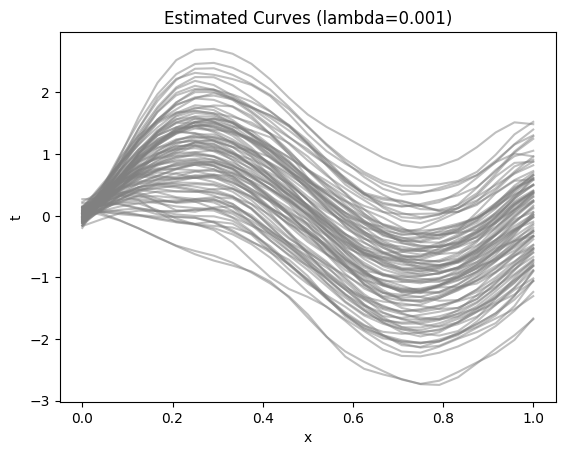

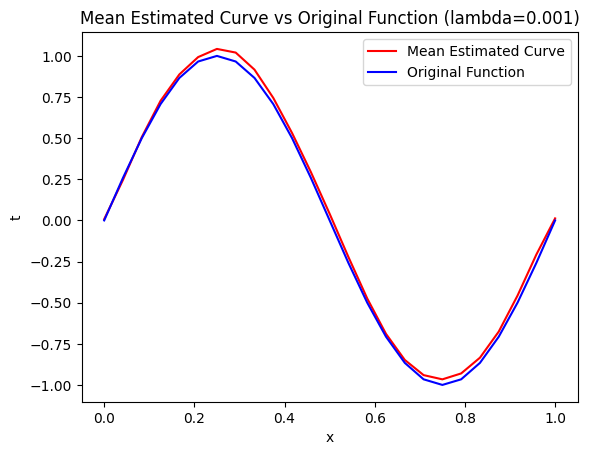

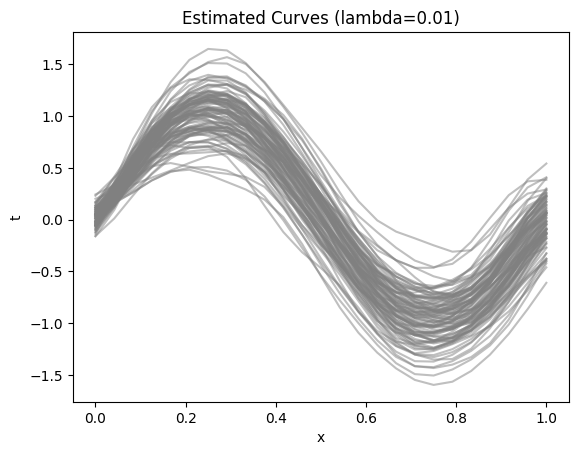

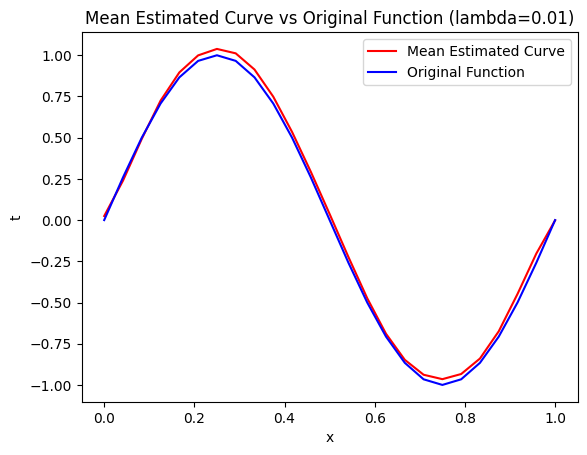

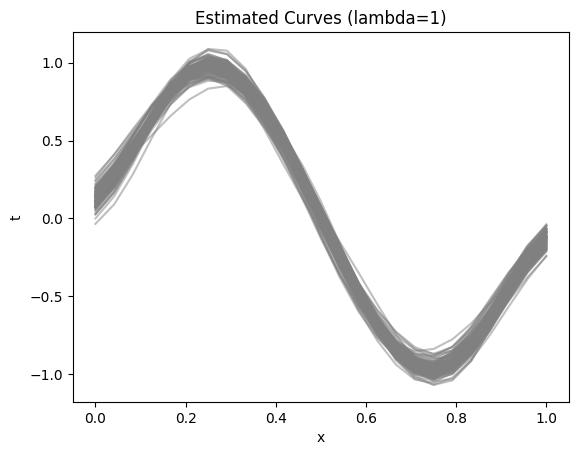

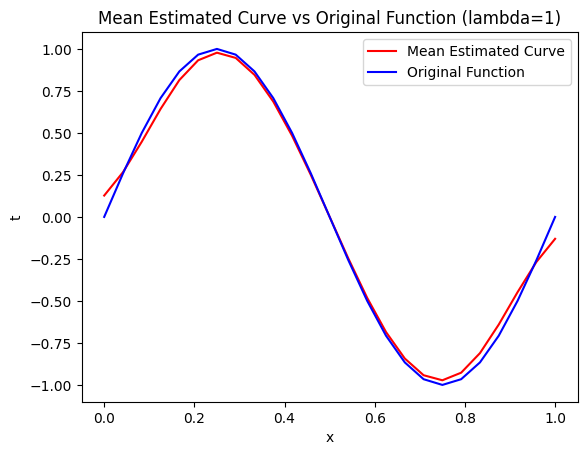

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Understanding the bias-variance trade-off
########################################
# Generate 100 data sets of noisy sinusoidal data
########################################
L = 100  # Number of datasets
N = 25  # Number of data points per dataset
X = np.zeros((L, N))  # Input data for all datasets
T = np.zeros((L, N))  # Target values for all datasets

for i in range(L):
    x = np.linspace(0, 1, N)  # Input values for current dataset
    noise = np.random.normal(0, 0.1, N)  # Gaussian noise for current dataset
    t = np.sin(2 * np.pi * x) + noise  # Target values for current dataset
    X[i, :] = x  # Store input data for current dataset
    T[i, :] = t  # Store target values for current dataset


########################################
# Use regularized least squares to estimate w
########################################
def gaussian_basis_function(x, mu, sigma):
    return np.exp(-((x - mu)**2) / (2 * sigma**2))

def regularized_least_squares(X, T, lamda, sigma): # Pass sigma as an argument
    M = 25  # Model order (number of basis functions + bias)
    #mus = np.linspace(0, 1, M - 1)  # Means of Gaussian basis functions # moved mus to be a global variable

    phi = np.zeros((N, M))  # Design matrix
    phi[:, 0] = 1  # Bias term
    for j in range(1, M):
        phi[:, j] = gaussian_basis_function(X, mus[j - 1], sigma)

    w = np.linalg.solve(phi.T @ phi + lamda * np.eye(M), phi.T @ T)  # Weight vector
    return w


########################################
# Illustrate the concept of Bias-Variance trade-off
########################################
lamdas = [0.001, 0.01, 1]  # Regularization coefficients (low, middle, high)
sigma = 0.1 # Define sigma globally
M = 25
mus = np.linspace(0, 1, M - 1)  # Means of Gaussian basis functions # define mus globally

for lamda in lamdas:
    # Produce two plots for each regularization coefficient

    # Plot 1: Displaying 100 estimated curves
    plt.figure()
    for i in range(L):
        w = regularized_least_squares(X[i, :], T[i, :], lamda, sigma) # Pass sigma to the function
        y = np.zeros(N)
        for j in range(len(w)):
            y += w[j] * gaussian_basis_function(X[i, :], mus[j - 1] if j > 0 else 0, sigma)  # Predicted values
        plt.plot(X[i, :], y, color='gray', alpha=0.5)  # Plot estimated curve
    plt.title(f'Estimated Curves (lambda={lamda})')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.show()

    # Plot 2: Showing the mean of the estimated curves alongside the original function
    plt.figure()
    mean_y = np.zeros(N)
    for i in range(L):
        w = regularized_least_squares(X[i, :], T[i, :], lamda, sigma)  # Pass sigma to the function
        y = np.zeros(N)
        for j in range(len(w)):
            y += w[j] * gaussian_basis_function(X[i, :], mus[j - 1] if j > 0 else 0, sigma)  # Predicted values
        mean_y += y  # Accumulate predicted values for averaging
    mean_y /= L  # Calculate mean predicted values
    plt.plot(X[0, :], mean_y, color='red', label='Mean Estimated Curve')  # Plot mean estimated curve
    plt.plot(X[0, :], np.sin(2 * np.pi * X[0, :]), color='blue', label='Original Function')  # Plot original function
    plt.title(f'Mean Estimated Curve vs Original Function (lambda={lamda})')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.legend()
    plt.show()

<b> Report your observations </b>

1.Low Regularization (λ=0.001): High variance is observed as the estimated curves vary widely, fitting noise in the data, but the mean curve closely matches the original function.



2.Moderate Regularization (λ=0.01): Balances bias and variance, with estimated curves showing less variability and the mean curve still aligning well with the original function.

3.High Regularization (λ=1): High bias is evident as the estimated curves are overly smooth, deviating from the original function, indicating underfitting.



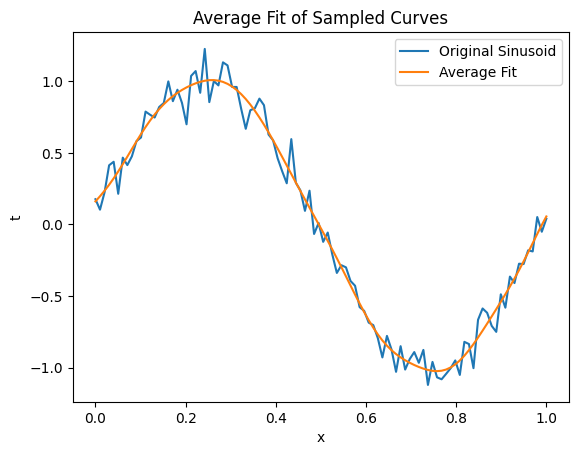

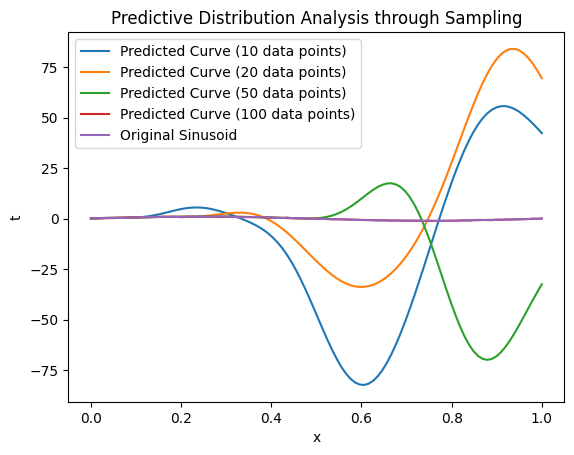

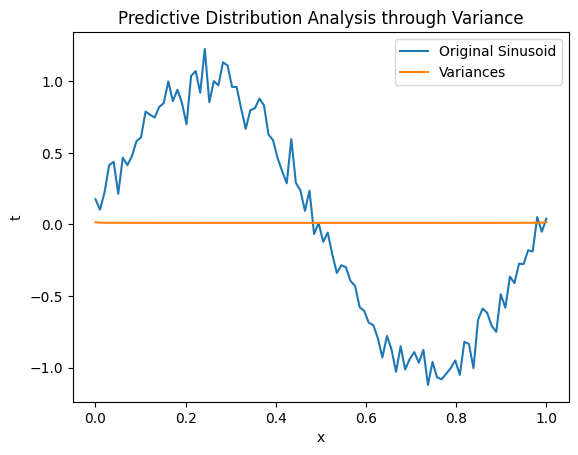

In [ ]:
# Understanding MAP estimate
########################################
# Generate 100 data sets of noisy sinusoidal data
########################################
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
N = 100  # Number of data points
x = np.linspace(0, 1, N)  # Input values
noise = np.random.normal(0, 0.1, N)  # Gaussian noise
t = np.sin(2 * np.pi * x) + noise  # Target values

########################################
# Update the statistics of posterior density
########################################
# Initialize the parameters for standard normal prior
M = 20  # Model order (number of basis functions + bias)
alpha = 1e-3  # Precision of prior distribution
beta = 1 / (0.1**2)  # Precision of noise

# Initialize mean and precision of posterior distribution
mu_prior = np.zeros(M)  # Prior mean
S_prior_inv = alpha * np.eye(M)  # Inverse of prior covariance matrix

# Gaussian basis functions
def gaussian_basis_function(x, mu, sigma):
    return np.exp(-((x - mu)**2) / (2 * sigma**2))

# Design matrix
mus = np.linspace(0, 1, M - 1)  # Means of Gaussian basis functions
phi = np.zeros((N, M))  # Design matrix
phi[:, 0] = 1  # Bias term
for j in range(1, M):
    phi[:, j] = gaussian_basis_function(x, mus[j - 1], sigma=0.1)

# Iterate through the data points and update the stats of posterior density
S_posterior_inv = S_prior_inv + beta * phi.T @ phi  # Inverse of posterior covariance matrix
mu_posterior = np.linalg.solve(S_posterior_inv, (S_prior_inv @ mu_prior + beta * phi.T @ t))  # Posterior mean

########################################
# Sample weight vector from posterior distribution. Estimate the curve, repeat the procedure for 100 times and get the avg fit
########################################
num_samples = 100  # Number of samples
sampled_weights = np.zeros((num_samples, M))  # Store sampled weight vectors
avg_fit = np.zeros(N)  # Store average fit

for i in range(num_samples):
    sampled_weights[i, :] = np.random.multivariate_normal(mu_posterior, np.linalg.inv(S_posterior_inv))  # Sample weight vector
    avg_fit += phi @ sampled_weights[i, :]  # Compute and accumulate fit

avg_fit /= num_samples  # Calculate average fit

# Plot average fit alongside original sinusoid
plt.plot(x, t, label='Original Sinusoid')
plt.plot(x, avg_fit, label='Average Fit')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Average Fit of Sampled Curves')
plt.legend()
plt.show()

########################################
# Predictive distribution analysis
########################################
# Predictive distribution analysis through sampling
# Iterate through data points and sample weight vectors when partial data points are seen, and plot the curves
num_partial_data = [10, 20, 50, 100]  # Number of partial data points to consider

for num_data in num_partial_data:
    S_posterior_inv_partial = S_prior_inv + beta * phi[:num_data, :].T @ phi[:num_data, :]  # Inverse of posterior covariance matrix with partial data
    mu_posterior_partial = np.linalg.solve(S_posterior_inv_partial, (S_prior_inv @ mu_prior + beta * phi[:num_data, :].T @ t[:num_data]))  # Posterior mean with partial data

    sampled_weights_partial = np.random.multivariate_normal(mu_posterior_partial, np.linalg.inv(S_posterior_inv_partial))  # Sample weight vector with partial data
    predicted_curve = phi @ sampled_weights_partial  # Compute predicted curve

    plt.plot(x, predicted_curve, label=f'Predicted Curve ({num_data} data points)')

plt.plot(x, t, label='Original Sinusoid')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predictive Distribution Analysis through Sampling')
plt.legend()
plt.show()

# Predictive distribution analysis through variance
# Iterate through data points and obtain necessary plots as discussed in the class
variances = np.zeros(N)  # Store variances for each data point

for i in range(N):
    phi_i = phi[i, :].reshape(1, -1)  # Design matrix for current data point
    variance_i = (phi_i @ np.linalg.solve(S_posterior_inv, phi_i.T)).item()
    variances[i] = 1 / beta + variance_i # Calculate variance

# Plot variances alongside original sinusoid
plt.plot(x, t, label='Original Sinusoid')
plt.plot(x, variances, label='Variances')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predictive Distribution Analysis through Variance')
plt.legend()
plt.show()

<b> Report your observations </b>

1.Posterior Mean Fit: The average fit of the sampled curves closely aligns with the original sinusoidal function, demonstrating the effectiveness of the MAP estimate in capturing the underlying pattern

2.Predictive Distribution with Partial Data: As more data points are included, the predicted curves become increasingly accurate, showing how the posterior distribution refines with additional observations.

3.Predictove Variance: The variance is higher in regions with fewer data points, indicating greater uncertainty, and decreases as more data is observed, reflecting improved confidence in predictions.

